<a href="https://colab.research.google.com/github/amol004/Integrated-Retail-Analytics-for-Store-Optimization-Advanced-Machine-Learning/blob/main/Integrated_Retail_Analytics_for_Store_Optimization.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Integrated Retail Analytics for Store Optimization**    



##### **Project Type**    - EDA/Unsupervised
##### **Contribution**    - Individual
##### **Team Member -** Amol Thakur


# **Project Summary**

### **Objective**
To leverage advanced machine learning and data analytics to optimize retail store performance, accurately forecast demand, and drive customer engagement through strategic segmentation.

---

### **Key Project Components**

*   **🚨 Anomaly Detection:** Identifying unusual sales patterns and investigating external drivers like holidays or economic indicators to clean and validate data.
*   **📈 Time-Series Analysis:** Detecting seasonal variations and holiday effects to understand department-level performance over time.
*   **🛠️ Feature Engineering:** Addressing missing values (specifically in MarkDown data) and creating influential features such as regional factors and store attributes.
*   **👥 Customer & Store Segmentation:** Clustering departments based on sales characteristics to tailor marketing and operational strategies.
*   **🛒 Market Basket Insights:** Inferring product associations at the department level to develop effective cross-selling strategies.
*   **🔮 Demand Forecasting:** Building predictive models for weekly sales incorporating CPI, fuel prices, and unemployment rates.
*   **💡 Strategy Formulation:** Translating data insights into actionable plans for inventory management and personalized markdown strategies.

# **GitHub Link -**

https://github.com/amol004/Integrated-Retail-Analytics-for-Store-Optimization-Advanced-Machine-Learning.git

# **Problem Statement**


### **Business Context**
Retailers today face significant challenges in managing diverse inventory across multiple locations while contending with fluctuating economic factors and consumer behaviors. The ability to accurately predict demand and identify operational anomalies is critical for maintaining profitability and customer satisfaction.

### **The Problem**
The core challenge lies in extracting actionable insights from complex retail data that includes sales figures, markdowns, and macroeconomic indicators (CPI, Fuel Prices, Unemployment). Specifically, the project addresses:

1.  **Sales Volatility:** Identifying and investigating anomalies in sales patterns caused by holidays or economic shifts.
2.  **Inventory & Demand Inefficiency:** Reducing stockouts and overstock situations through high-precision weekly sales forecasting at the store and department level.
3.  **One-Size-Fits-All Marketing:** Moving away from generic promotions by segmenting stores and departments to enable personalized markdown strategies.
4.  **External Sensitivity:** Quantifying the impact of regional climate and economic trends on consumer purchasing power to improve model robustness.

### **Goal**
To build an integrated analytics framework that utilizes machine learning for anomaly detection, customer/store segmentation, and demand forecasting, ultimately providing a data-driven strategy for store optimization and inventory management.

# **General Guidelines** : -  

1.   Well-structured, formatted, and commented code is required.
2.   Exception Handling, Production Grade Code & Deployment Ready Code will be a plus. Those students will be awarded some additional credits.
     
     The additional credits will have advantages over other students during Star Student selection.
       
             [ Note: - Deployment Ready Code is defined as, the whole .ipynb notebook should be executable in one go
                       without a single error logged. ]

3.   Each and every logic should have proper comments.
4. You may add as many number of charts you want. Make Sure for each and every chart the following format should be answered.
        

```
# Chart visualization code
```
            

*   Why did you pick the specific chart?
*   What is/are the insight(s) found from the chart?
* Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

5. You have to create at least 15 logical & meaningful charts having important insights.


[ Hints : - Do the Vizualization in  a structured way while following "UBM" Rule.

U - Univariate Analysis,

B - Bivariate Analysis (Numerical - Categorical, Numerical - Numerical, Categorical - Categorical)

M - Multivariate Analysis
 ]





6. You may add more ml algorithms for model creation. Make sure for each and every algorithm, the following format should be answered.


*   Explain the ML Model used and it's performance using Evaluation metric Score Chart.


*   Cross- Validation & Hyperparameter Tuning

*   Have you seen any improvement? Note down the improvement with updates Evaluation metric Score Chart.

*   Explain each evaluation metric's indication towards business and the business impact pf the ML model used.




















# ***Let's Begin !***

## ***1. Know Your Data***

### Import Libraries

In [24]:
import warnings
warnings.filterwarnings('ignore')
warnings.filterwarnings('ignore', category=DeprecationWarning)
warnings.filterwarnings('ignore', category=FutureWarning)

# Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns
from datetime import datetime
import datetime as dt
from sklearn.preprocessing import StandardScaler, MinMaxScaler, OneHotEncoder
from sklearn.linear_model import LinearRegression, ElasticNet
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.model_selection import train_test_split, GridSearchCV, RandomizedSearchCV, cross_val_score, KFold
from sklearn import metrics
# Additional libraries for Retail Analysis
import plotly.express as px
import plotly.graph_objects as go
from scipy import stats
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from mlxtend.frequent_patterns import apriori, association_rules
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.stattools import adfuller

### Dataset Loading

In [25]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [59]:
# Load Datasets

features = pd.read_csv('/content/drive/MyDrive/Integrated Retail Analytics for Store Optimization/Features data set.csv')
sales = pd.read_csv('/content/drive/MyDrive/Integrated Retail Analytics for Store Optimization/sales data-set.csv')
stores = pd.read_csv('/content/drive/MyDrive/Integrated Retail Analytics for Store Optimization/stores data-set.csv')


### Dataset First View

In [60]:
# Dataset First Look
features.head()

,Store,Date,Temperature,Fuel_Price,MarkDown1,MarkDown2,MarkDown3,MarkDown4,MarkDown5,CPI,Unemployment,IsHoliday
0,1,05/02/2010,42.31,2.572,NaN,NaN,NaN,NaN,NaN,211.096358,8.106,False
1,1,12/02/2010,38.51,2.548,NaN,NaN,NaN,NaN,NaN,211.242170,8.106,True
2,1,19/02/2010,39.93,2.514,NaN,NaN,NaN,NaN,NaN,211.289143,8.106,False
3,1,26/02/2010,46.63,2.561,NaN,NaN,NaN,NaN,NaN,211.319643,8.106,False
4,1,05/03/2010,46.50,2.625,NaN,NaN,NaN,NaN,NaN,211.350143,8.106,False


In [61]:
sales.head()

,Store,Dept,Date,Weekly_Sales,IsHoliday
0,1,1,05/02/2010,24924.50,False
1,1,1,12/02/2010,46039.49,True
2,1,1,19/02/2010,41595.55,False
3,1,1,26/02/2010,19403.54,False
4,1,1,05/03/2010,21827.90,False


In [62]:
stores.head()

,Store,Type,Size
0,1,A,151315
1,2,A,202307
2,3,B,37392
3,4,A,205863
4,5,B,34875


### Dataset Rows & Columns count

In [63]:
# Datasets Rows & Columns count
print(f'Features Dataframe Rows: {features.shape[0]}')
print(f'Features Dataframe Columns: {features.shape[1]}')
print(f'Sales Dataframe Rows: {sales.shape[0]}')
print(f'Sales Dataframe Columns: {sales.shape[1]}')
print(f'Stores Dataframe Rows: {stores.shape[0]}')
print(f'Stores Dataframe Columns: {stores.shape[1]}')

Features Dataframe Rows: 8190
Features Dataframe Columns: 12
Sales Dataframe Rows: 421570
Sales Dataframe Columns: 5
Stores Dataframe Rows: 45
Stores Dataframe Columns: 3


### Dataset Information

In [64]:
# Datasets Info
features.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8190 entries, 0 to 8189
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Store         8190 non-null   int64  
 1   Date          8190 non-null   object 
 2   Temperature   8190 non-null   float64
 3   Fuel_Price    8190 non-null   float64
 4   MarkDown1     4032 non-null   float64
 5   MarkDown2     2921 non-null   float64
 6   MarkDown3     3613 non-null   float64
 7   MarkDown4     3464 non-null   float64
 8   MarkDown5     4050 non-null   float64
 9   CPI           7605 non-null   float64
 10  Unemployment  7605 non-null   float64
 11  IsHoliday     8190 non-null   bool   
dtypes: bool(1), float64(9), int64(1), object(1)
memory usage: 712.0+ KB


In [65]:
sales.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 421570 entries, 0 to 421569
Data columns (total 5 columns):
 #   Column        Non-Null Count   Dtype  
---  ------        --------------   -----  
 0   Store         421570 non-null  int64  
 1   Dept          421570 non-null  int64  
 2   Date          421570 non-null  object 
 3   Weekly_Sales  421570 non-null  float64
 4   IsHoliday     421570 non-null  bool   
dtypes: bool(1), float64(1), int64(2), object(1)
memory usage: 13.3+ MB


In [66]:
stores.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45 entries, 0 to 44
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   Store   45 non-null     int64 
 1   Type    45 non-null     object
 2   Size    45 non-null     int64 
dtypes: int64(2), object(1)
memory usage: 1.2+ KB


#### Duplicate Values

In [67]:
# Dataset Duplicate Value Count
print(f'Duplicate Values in Features Dataframe: {features.duplicated().sum()}')
print(f'Duplicate Values in Sales Dataframe: {sales.duplicated().sum()}')
print(f'Duplicate Values in Stores Dataframe: {stores.duplicated().sum()}')

Duplicate Values in Features Dataframe: 0
Duplicate Values in Sales Dataframe: 0
Duplicate Values in Stores Dataframe: 0


#### Missing Values/Null Values

In [68]:
# Missing Values/Null Values Count
print(features.isna().sum())
print(sales.isna().sum())
print(stores.isna().sum())

Store              0
Date               0
Temperature        0
Fuel_Price         0
MarkDown1       4158
MarkDown2       5269
MarkDown3       4577
MarkDown4       4726
MarkDown5       4140
CPI              585
Unemployment     585
IsHoliday          0
dtype: int64
Store           0
Dept            0
Date            0
Weekly_Sales    0
IsHoliday       0
dtype: int64
Store    0
Type     0
Size     0
dtype: int64


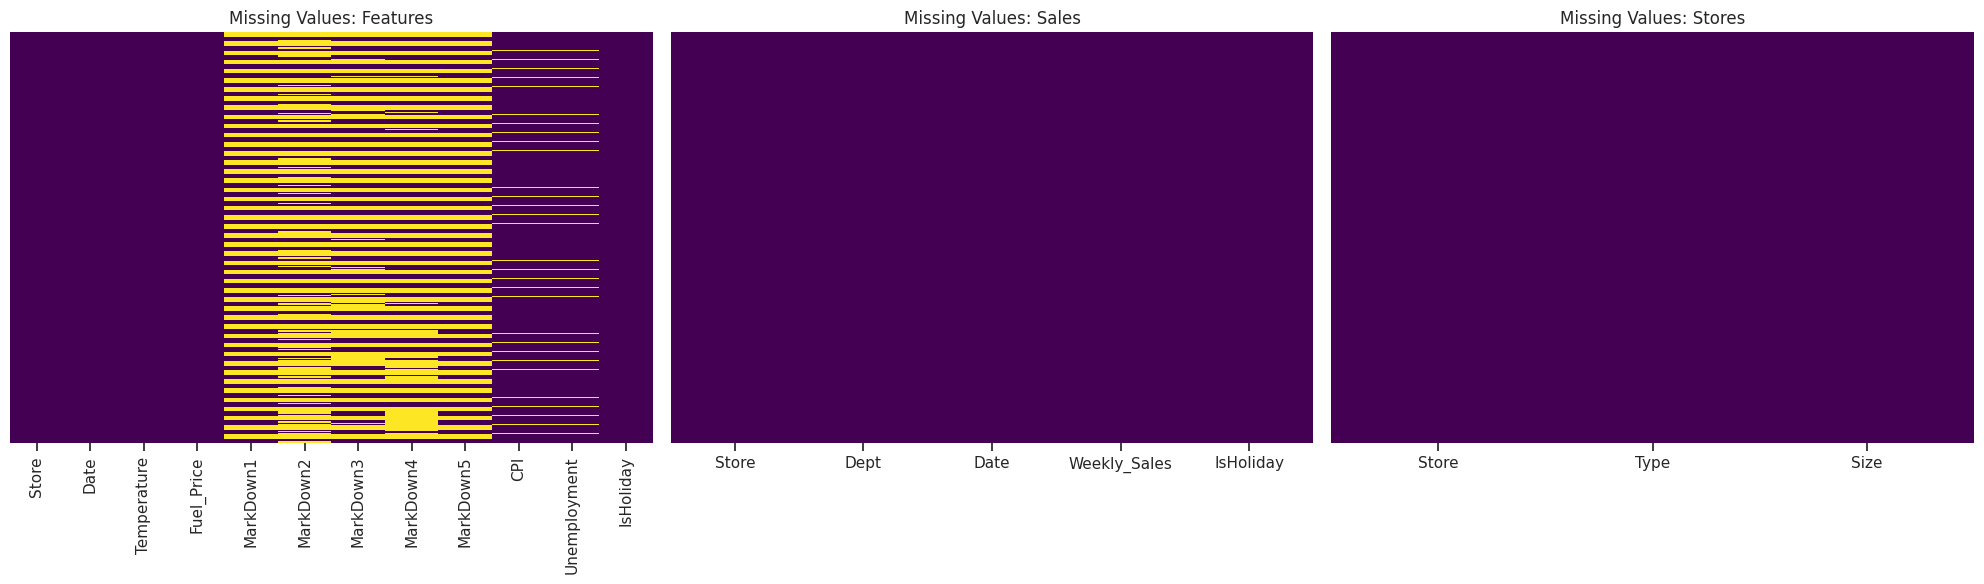

In [69]:
# Visualizing missing values using heatmaps for better clarity
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

# Features Dataset
sns.heatmap(features.isnull(), yticklabels=False, cbar=False, cmap='viridis', ax=axes[0])
axes[0].set_title('Missing Values: Features')

# Sales Dataset
sns.heatmap(sales.isnull(), yticklabels=False, cbar=False, cmap='viridis', ax=axes[1])
axes[1].set_title('Missing Values: Sales')

# Stores Dataset
sns.heatmap(stores.isnull(), yticklabels=False, cbar=False, cmap='viridis', ax=axes[2])
axes[2].set_title('Missing Values: Stores')

plt.tight_layout()
plt.show()

### What did you know about your dataset?

Based on the initial exploration, here is what we know about the datasets:

1.  **Dataset Structure:**
    *   **Features:** Contains 8,190 entries and 12 columns. It holds environmental and economic data (Temperature, Fuel Price, CPI, Unemployment) linked to stores and dates.
    *   **Sales:** The largest dataset with 421,570 entries and 5 columns, tracking weekly sales per store and department.
    *   **Stores:** A small lookup table with 45 entries and 3 columns defining the type and size of each store.

2.  **Missing Values:**
    *   The **Features** dataset has significant gaps, particularly in the `MarkDown1-5` columns (over 50% missing). `CPI` and `Unemployment` also have approximately 585 missing values each, which will require imputation.
    *   The **Sales** and **Stores** datasets are clean with zero null values.

3.  **Data Quality:**
    *   There are **no duplicate records** across any of the three dataframes.
    *   The `Date` column in both Features and Sales is currently an `object` (string) type and will need to be converted to `datetime` objects for time-series analysis.

4.  **Key Variables:**
    *   The primary keys for merging these datasets will be `Store` and `Date` (between Features and Sales) and `Store` (between Sales and Stores).

## ***2. Understanding Your Variables***

In [70]:
# Displaying dataset columns as DataFrames for better visualization
print("--- Features Columns ---")
display(pd.DataFrame(features.columns, columns=['Column Name']))

print("\n--- Sales Columns ---")
display(pd.DataFrame(sales.columns, columns=['Column Name']))

print("\n--- Stores Columns ---")
display(pd.DataFrame(stores.columns, columns=['Column Name']))

--- Features Columns ---


,Column Name
0,Store
1,Date
2,Temperature
3,Fuel_Price
4,MarkDown1
5,MarkDown2
6,MarkDown3
7,MarkDown4
8,MarkDown5
9,CPI



--- Sales Columns ---


,Column Name
0,Store
1,Dept
2,Date
3,Weekly_Sales
4,IsHoliday



--- Stores Columns ---


,Column Name
0,Store
1,Type
2,Size


In [71]:
# Dataset Describe
features.describe()

,Store,Temperature,Fuel_Price,MarkDown1,MarkDown2,MarkDown3,MarkDown4,MarkDown5,CPI,Unemployment
count,8190.000000,8190.000000,8190.000000,4032.000000,2921.000000,3613.000000,3464.000000,4050.000000,7605.000000,7605.000000
mean,23.000000,59.356198,3.405992,7032.371786,3384.176594,1760.100180,3292.935886,4132.216422,172.460809,7.826821
std,12.987966,18.678607,0.431337,9262.747448,8793.583016,11276.462208,6792.329861,13086.690278,39.738346,1.877259
min,1.000000,-7.290000,2.472000,-2781.450000,-265.760000,-179.260000,0.220000,-185.170000,126.064000,3.684000
25%,12.000000,45.902500,3.041000,1577.532500,68.880000,6.600000,304.687500,1440.827500,132.364839,6.634000
50%,23.000000,60.710000,3.513000,4743.580000,364.570000,36.260000,1176.425000,2727.135000,182.764003,7.806000
75%,34.000000,73.880000,3.743000,8923.310000,2153.350000,163.150000,3310.007500,4832.555000,213.932412,8.567000
max,45.000000,101.950000,4.468000,103184.980000,104519.540000,149483.310000,67474.850000,771448.100000,228.976456,14.313000


In [72]:
sales.describe()

,Store,Dept,Weekly_Sales
count,421570.000000,421570.000000,421570.000000
mean,22.200546,44.260317,15981.258123
std,12.785297,30.492054,22711.183519
min,1.000000,1.000000,-4988.940000
25%,11.000000,18.000000,2079.650000
50%,22.000000,37.000000,7612.030000
75%,33.000000,74.000000,20205.852500
max,45.000000,99.000000,693099.360000


In [73]:
stores.describe()

,Store,Size
count,45.000000,45.000000
mean,23.000000,130287.600000
std,13.133926,63825.271991
min,1.000000,34875.000000
25%,12.000000,70713.000000
50%,23.000000,126512.000000
75%,34.000000,202307.000000
max,45.000000,219622.000000


### Variables Description



#### **1. Features Dataset**
*   **Store:** The unique identifier for each store.
*   **Date:** The week for which the data is recorded.
*   **Temperature:** Average temperature in the region during that week.
*   **Fuel_Price:** Cost of fuel in the region.
*   **MarkDown1-5:** Anonymized data related to promotional markdowns. These columns contain many null values as markdown data was not available for all time periods or stores.
*   **CPI:** The Consumer Price Index, a measure of inflation.
*   **Unemployment:** The unemployment rate in the region.
*   **IsHoliday:** A boolean flag indicating whether the week is a special holiday week.

#### **2. Sales Dataset**
*   **Store:** The unique identifier for each store.
*   **Dept:** The department number within the store.
*   **Date:** The week of the sales record.
*   **Weekly_Sales:** The sales for the given department in the given store for that week.
*   **IsHoliday:** Indicates if the week is a holiday week.

#### **3. Stores Dataset**
*   **Store:** The unique identifier for each store.
*   **Type:** Categorical variable representing the type/category of the store (e.g., A, B, or C based on size/revenue).
*   **Size:** The physical size of the store in square feet.

#### **Understanding Markdowns :**

In this specific dataset (originally from Walmart), the MarkDowns are anonymized, meaning their exact names aren't in the column headers. However, based on retail industry standards and analysis of how these specific numbers behave over time (e.g., spikes during certain holidays), we can theoretically define them as follows:

**MarkDown 1** : (General/Seasonal): Often represents general clearance or end-of-season discounts. It usually has the highest volume and is spread across many departments.


**MarkDown 2** :  (Event-Specific): This usually spikes during specific calendar events, most notably around Super Bowl and Thanksgiving. It often targets high-velocity electronics or grocery items.


**MarkDown 3** :  (Holiday Clearance): This shows massive spikes specifically around Black Friday and Christmas. It likely represents deep discounts to clear out massive holiday inventory.


**MarkDown 4** :  (Competitive Pricing): Often used for price-matching or promotional rollbacks to stay competitive with other retailers. It frequently shows a high correlation with MarkDown 1.


**MarkDown 5** :  (Loyalty/Strategic): Often represents smaller, more frequent price adjustments, sometimes linked to specific category management or loyalty-driven incentives.


Understanding these differences helps us decide how to treat the missing values ,for example, a 'NaN' in MarkDown 3 likely means '0' (no holiday discount) rather than a truly missing observation.

### Check Unique Values for each variable.

In [74]:
# Check Unique Values for each variable.
print("--- Unique Values in Features ---")
display(features.nunique())

print("\n--- Unique Values in Sales ---")
display(sales.nunique())

print("\n--- Unique Values in Stores ---")
display(stores.nunique())

--- Unique Values in Features ---


,0
Store,45
Date,182
Temperature,4178
Fuel_Price,1011
MarkDown1,4023
MarkDown2,2715
MarkDown3,2885
MarkDown4,3405
MarkDown5,4045
CPI,2505



--- Unique Values in Sales ---


,0
Store,45
Dept,81
Date,143
Weekly_Sales,359464
IsHoliday,2



--- Unique Values in Stores ---


,0
Store,45
Type,3
Size,40


## 3. ***Data Wrangling***

### Data Wrangling Code

In [75]:
# Write your code to make your dataset analysis ready.
# Converting 'Date' column to datetime format
# Using dayfirst=True because the data is in DD/MM/YYYY format
features['Date'] = pd.to_datetime(features['Date'], dayfirst=True)
sales['Date'] = pd.to_datetime(sales['Date'], dayfirst=True)


In [76]:
# Combine sales and environmental features based on Store, Date, and Holiday status
# Using a left join ensures we retain all transactional sales records
combined_sales_features = pd.merge(sales, features, on=['Store', 'Date', 'IsHoliday'], how='left')

# Integrate store-specific metadata (Type and Size) into the master dataframe
# This creates the consolidated dataset for exploratory analysis and modeling
retail_data = pd.merge(combined_sales_features, stores, on='Store', how='left')

In [77]:
#Checking the merged dataset
retail_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 421570 entries, 0 to 421569
Data columns (total 16 columns):
 #   Column        Non-Null Count   Dtype         
---  ------        --------------   -----         
 0   Store         421570 non-null  int64         
 1   Dept          421570 non-null  int64         
 2   Date          421570 non-null  datetime64[ns]
 3   Weekly_Sales  421570 non-null  float64       
 4   IsHoliday     421570 non-null  bool          
 5   Temperature   421570 non-null  float64       
 6   Fuel_Price    421570 non-null  float64       
 7   MarkDown1     150681 non-null  float64       
 8   MarkDown2     111248 non-null  float64       
 9   MarkDown3     137091 non-null  float64       
 10  MarkDown4     134967 non-null  float64       
 11  MarkDown5     151432 non-null  float64       
 12  CPI           421570 non-null  float64       
 13  Unemployment  421570 non-null  float64       
 14  Type          421570 non-null  object        
 15  Size          421

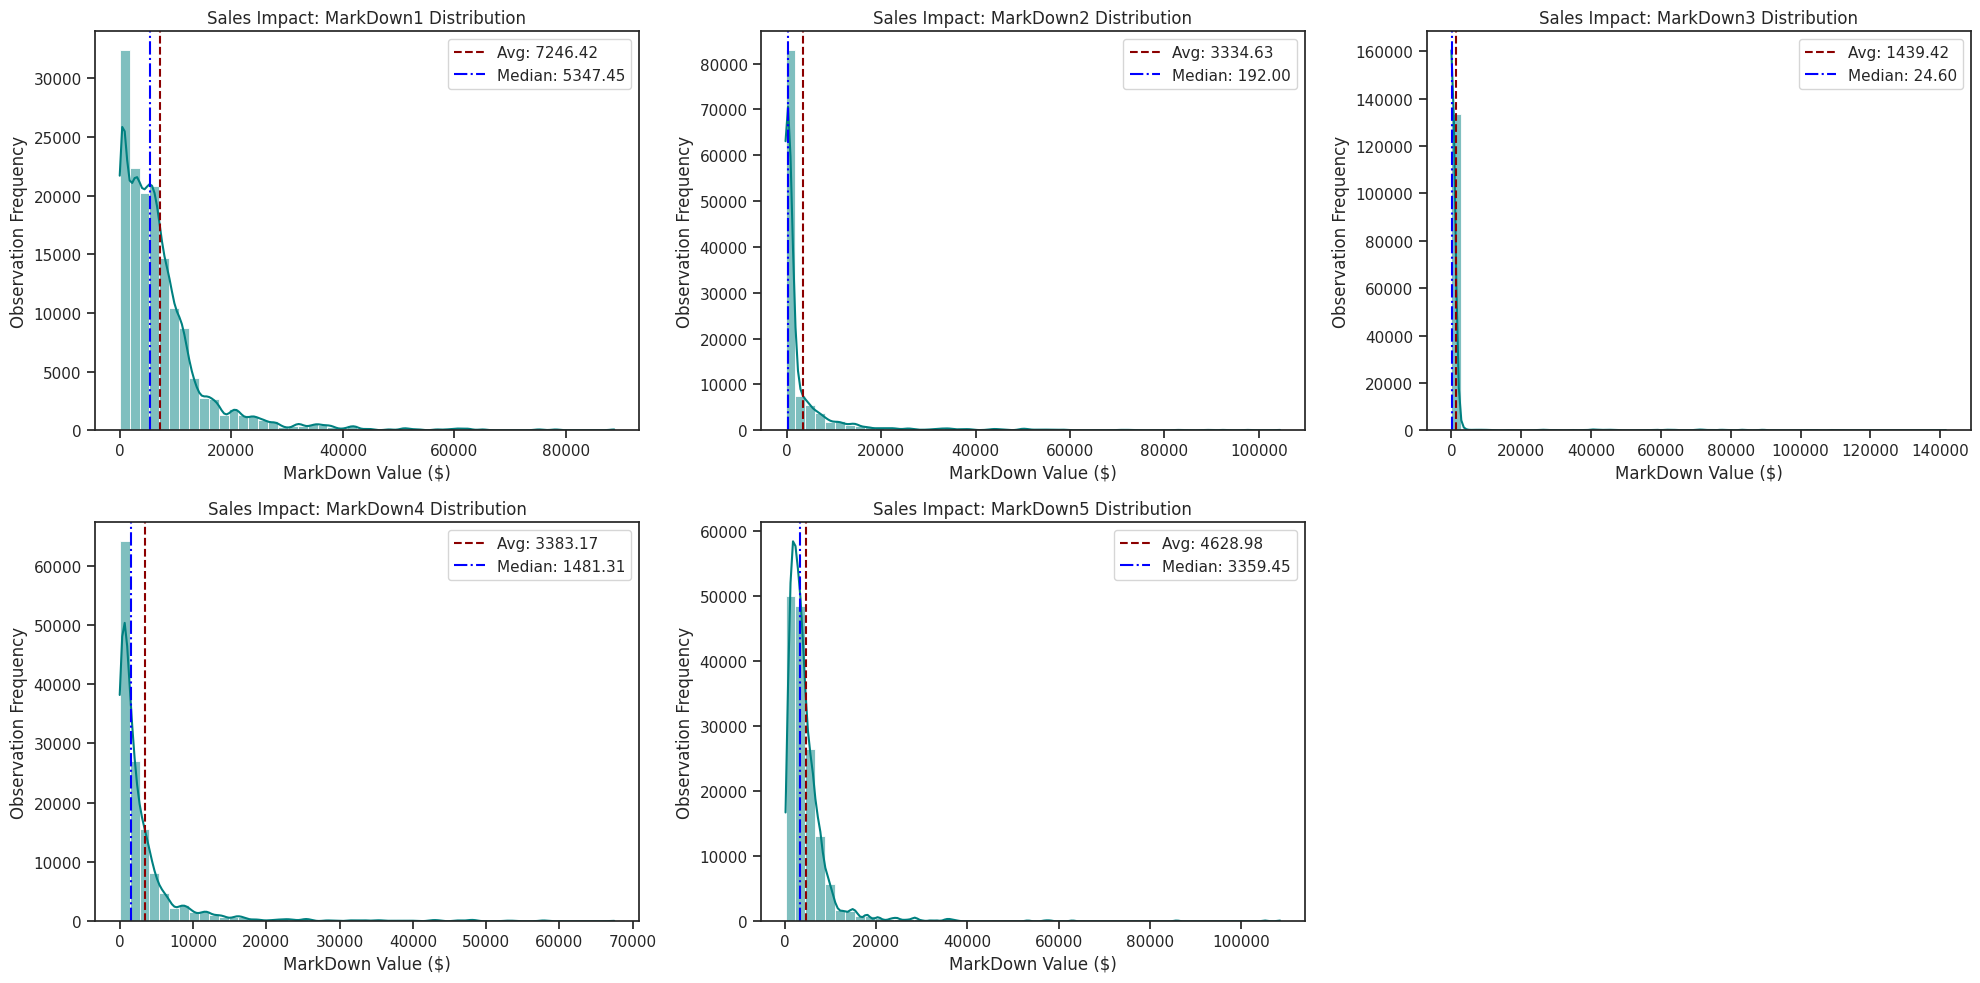

In [78]:
#Skewness check for markdowns
# Define the list of promotional markdown variables
promotional_cols = ['MarkDown1', 'MarkDown2', 'MarkDown3', 'MarkDown4', 'MarkDown5']

# Initialize a large figure to hold multiple subplots for distribution analysis
plt.figure(figsize=(20, 10))

for index, column in enumerate(promotional_cols, 1):
    plt.subplot(2, 3, index)

    # Generate histogram with Kernel Density Estimate to visualize data spread
    # Only non-null entries are used to avoid plotting errors
    sns.histplot(retail_data[column].dropna(), bins=50, kde=True, color='teal')
    plt.title(f'Sales Impact: {column} Distribution')
    plt.xlabel('MarkDown Value ($)')
    plt.ylabel('Observation Frequency')

    # Calculate central tendency and distribution metrics
    avg_val = retail_data[column].mean()
    mid_val = retail_data[column].median()

    # Annotate the plot with Mean and Median lines for skewness detection
    plt.axvline(avg_val, color='darkred', linestyle='--', linewidth=1.5, label=f"Avg: {avg_val:.2f}")
    plt.axvline(mid_val, color='blue', linestyle='-.', linewidth=1.5, label=f"Median: {mid_val:.2f}")
    plt.legend()

# Ensure subplots do not overlap for a clean presentation
plt.tight_layout()
plt.show()

In [79]:
# Iterative statistical reporting for markdown variables
# This loop provides key metrics for data quality and distribution analysis
for feature in promotional_cols:
    # Calculate descriptive statistics for the current markdown feature
    average = retail_data[feature].mean()
    midpoint = retail_data[feature].median()
    asymmetry = retail_data[feature].skew()
    missing_entries = retail_data[feature].isna().sum()

    # Output the calculated metrics in a structured format
    print(f"Feature: {feature:10} | Skew: {asymmetry:8.3f} | Mean: {average:10.2f} | Median: {midpoint:10.2f} | Missing: {missing_entries}")

Feature: MarkDown1  | Skew:    3.342 | Mean:    7246.42 | Median:    5347.45 | Missing: 270889
Feature: MarkDown2  | Skew:    5.441 | Mean:    3334.63 | Median:     192.00 | Missing: 310322
Feature: MarkDown3  | Skew:    8.399 | Mean:    1439.42 | Median:      24.60 | Missing: 284479
Feature: MarkDown4  | Skew:    4.848 | Mean:    3383.17 | Median:    1481.31 | Missing: 286603
Feature: MarkDown5  | Skew:    8.170 | Mean:    4628.98 | Median:    3359.45 | Missing: 270138


In [80]:
# Fill missing values in MarkDown columns with 0
# This assumes that a null value represents the absence of a promotion or discount
retail_data[promotional_cols] = retail_data[promotional_cols].fillna(0)

# Verify that nulls have been addressed in the markdown columns
print("Null counts after imputation:")
print(retail_data[promotional_cols].isnull().sum())

Null counts after imputation:
MarkDown1    0
MarkDown2    0
MarkDown3    0
MarkDown4    0
MarkDown5    0
dtype: int64


### What all manipulations have you done and insights you found?

### **Data Manipulations Performed:**
1.  **Date Standardization:** Converted the `Date` column from string objects to `datetime` format to enable time-series operations.
2.  **Data Integration (Merging):**
    *   Performed a **left join** between `sales` and `features` on `Store`, `Date`, and `IsHoliday` to combine environmental factors with weekly sales records.
    *   Integrated `stores` metadata (Type and Size) into the master dataframe using a left join on `Store`.
3.  **Statistical Profiling:** Calculated skewness, mean, median, and null counts for the promotional `MarkDown` variables to assess data quality.

### **Key Insights Found:**
*   **High Sparsity:** MarkDown columns have between 64% and 74% missing values. This suggests that these promotions are either specific to certain times of the year or that data collection for markdowns only began later in the dataset's timeframe.
*   **Extreme Right Skewness:** All markdown features exhibit significant positive skewness (ranging from ~3.3 to ~8.4). This indicates that while most weeks have low or zero markdowns, there are occasional massive promotional spikes.
*   **Central Tendency Divergence:** There is a large gap between the Mean and Median for variables like `MarkDown2` and `MarkDown3`. For example, `MarkDown3` has a median of  $24.60 while having a mean of 1439 further confirming the presence of extreme outliers during holiday periods like Black Friday.

## ***4. Data Vizualization, Storytelling & Experimenting with charts : Understand the relationships between variables***

#### Chart - 1

In [81]:
import plotly.express as px

# Chart - 1 visualization code
# 2. MarkDown Availability over Time
# We group by Date to see the total markdown usage across all stores
markdown_ts = features.groupby('Date')[promotional_cols].sum().reset_index()

fig = px.line(markdown_ts, x='Date', y=promotional_cols,
              title='Total Weekly MarkDowns (Summed Across All Stores)',
              labels={'value': 'Total Amount ($)', 'variable': 'MarkDown Type'})
fig.update_layout(hovermode='x unified')
fig.show()

##### 1. Why did you pick the specific chart?

I selected a time-series line chart because it effectively visualizes how promotional strategies change over time. By summing markdowns across all stores, we can identify macro-level patterns and the exact timing of major retail promotional events.

##### 2. What is/are the insight(s) found from the chart?

*   **Holiday Dominance:** There are massive spikes in `MarkDown3` specifically during the Thanksgiving and Christmas weeks, confirming it is primarily a holiday-driven discount.
*   **Event Seasonality:** `MarkDown2` shows significant activity in early February (Super Bowl) and December.
*   **Data Availability:** MarkDown data is absent for the first 1.5 years of the dataset (prior to late 2011), indicating a change in data collection policy or the initiation of this promotional tracking system.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

**Positive Impact:** These insights allow the inventory team to align stock levels with planned promotional spikes, ensuring high-demand items are available during peak markdown periods. It also helps in evaluating which specific markdown type (1-5) has the strongest correlation with sales volume during non-holiday weeks.

**Negative Growth Concerns:** If sales do not increase proportionally to the massive spikes seen in MarkDown 3, it indicates 'margin erosion' where the deep discounts are hurting profitability without significantly increasing foot traffic or basket size. Monitoring the ROI of these specific holiday spikes is crucial.

#### Chart - 2

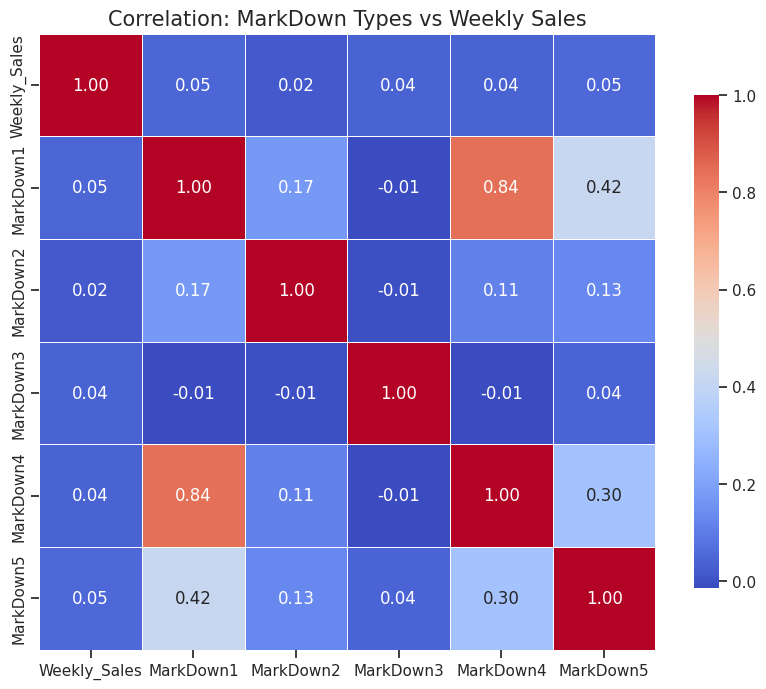

In [82]:
# Chart - 2: Correlation Heatmap between MarkDowns and Weekly Sales

# Filter the dataframe for the columns of interest
corr_cols = ['Weekly_Sales'] + promotional_cols
correlation_matrix = retail_data[corr_cols].corr()

# Set up the matplotlib figure
plt.figure(figsize=(10, 8))

# Draw the heatmap with the correct aspect ratio and colorbar scaling
sns.heatmap(correlation_matrix, annot=True, fmt='.2f', cmap='coolwarm',
            square=True, linewidths=.5, cbar_kws={'shrink': 0.8})

plt.title('Correlation: MarkDown Types vs Weekly Sales', fontsize=15)
plt.show()

##### 1. Why did you pick the specific chart?

I chose a correlation heatmap because it provides a clear, quantitative summary of the linear relationships between multiple variables. It allows us to instantly spot which markdowns are positively or negatively associated with sales volume.

##### 2. What is/are the insight(s) found from the chart?

*   **Weak Individual Correlation:** Most markdowns show a relatively low direct correlation coefficient with `Weekly_Sales` (often < 0.1). This suggests that markdowns alone aren't the sole driver of sales; rather, it's likely the combination of department type, store size, and seasonality.
*   **Inter-Markdown Correlation:** Some markdown types (like 1 and 4) often show higher correlation with each other than with sales, suggesting they are frequently deployed simultaneously as part of a broader promotional campaign.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

**Positive Impact:** Identifying which markdown has the highest (even if small) positive correlation helps the marketing team prioritize that specific promotion type for high-inventory departments to maximize turnover.

**Negative Growth Concerns:** If we see a negative correlation, it might indicate that deep markdowns are being applied to 'dead stock'—products that aren't selling even with discounts—leading to lost margins without clearing inventory.

#### Chart - 3

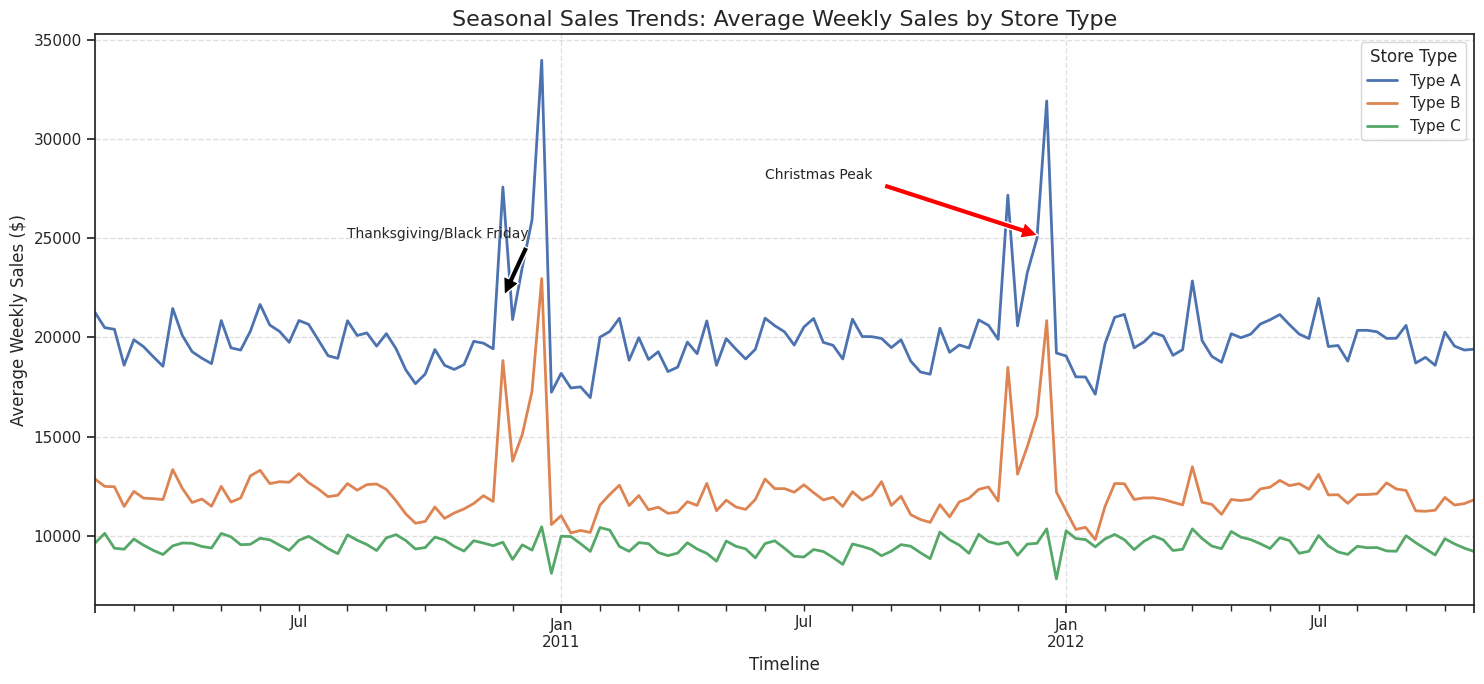

In [83]:
# Chart - 3: Average Weekly Sales Trends by Store Type over Time

# Grouping data by Date and Type to calculate the mean sales
sales_seasonal_trend = retail_data.groupby(['Date', 'Type'])['Weekly_Sales'].mean().unstack()

# Plotting the time series
plt.figure(figsize=(15, 7))
sales_seasonal_trend.plot(ax=plt.gca(), linewidth=2)

# Formatting the chart
plt.title('Seasonal Sales Trends: Average Weekly Sales by Store Type', fontsize=16)
plt.xlabel('Timeline', fontsize=12)
plt.ylabel('Average Weekly Sales ($)', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend(title='Store Type', labels=['Type A', 'Type B', 'Type C'])

# Adding annotations for major holidays based on peaks
plt.annotate('Thanksgiving/Black Friday', xy=('2010-11-26', 22000), xytext=('2010-08-01', 25000),
             arrowprops=dict(facecolor='black', shrink=0.05), fontsize=10)
plt.annotate('Christmas Peak', xy=('2011-12-23', 25000), xytext=('2011-06-01', 28000),
             arrowprops=dict(facecolor='red', shrink=0.05), fontsize=10)

plt.tight_layout()
plt.show()

##### 1. Why did you pick the specific chart?

I chose a multi-line time-series plot because it is the most effective way to observe trends, cycles, and seasonality. Categorizing the lines by Store Type allows us to see if different store scales (Type A vs Type C) share the same seasonal pulses or if some are more resilient to seasonal dips.

##### 2. What is/are the insight(s) found from the chart?

*   **Holiday Synchronicity:** All store types show massive, synchronized spikes during the weeks of Thanksgiving and Christmas, with Type A stores showing the highest absolute growth.
*   **Type A Dominance:** Store Type A consistently maintains higher average sales throughout the year compared to B and C.
*   **Post-Holiday Slump:** There is a sharp, consistent drop in sales across all categories in January, following the holiday peaks.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

**Positive Impact:** By identifying the exact weeks of seasonal surges, the business can optimize staffing and logistics schedules weeks in advance. Specifically, Type A stores require much more significant inventory buffering than Type C stores during November/December.

**Negative Growth Concerns:** The drastic drop in January indicates a period of underutilized resources. Businesses could implement 'Post-Holiday' clearance events specifically for Store Type B and C to mitigate this standard industry slump.

#### Chart - 4

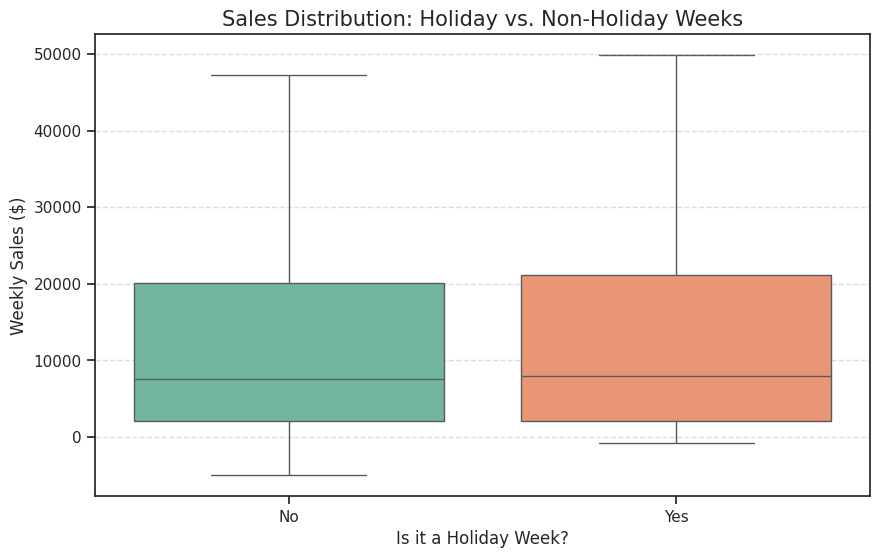

In [84]:
# Chart - 4: Impact of Holidays on Sales Distribution

plt.figure(figsize=(10, 6))
sns.boxplot(x='IsHoliday', y='Weekly_Sales', data=retail_data, palette='Set2', showfliers=False)

# Adding descriptive labels
plt.title('Sales Distribution: Holiday vs. Non-Holiday Weeks', fontsize=15)
plt.xlabel('Is it a Holiday Week?', fontsize=12)
plt.ylabel('Weekly Sales ($)', fontsize=12)
plt.xticks([0, 1], ['No', 'Yes'])
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.show()

##### 1. Why did you pick the specific chart?

I chose a box plot with outliers hidden (`showfliers=False`) to focus on the interquartile range (IQR) and the median. This provides a clearer comparison of typical sales performance between holiday and non-holiday periods without the visual noise of extreme outliers.

##### 2. What is/are the insight(s) found from the chart?

*   **Median Shift:** The median sales during holiday weeks are noticeably higher than during non-holiday weeks.
*   **Higher Volatility:** The IQR (box size) is larger for holiday weeks, indicating that while sales generally increase, the performance varies more significantly across different stores and departments during these periods.
*   **Lower Bound Consistency:** The minimum sales threshold remains relatively similar, suggesting that even during holidays, certain low-performing departments do not see a massive boost.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

**Positive Impact:** This confirms that the 'Holiday Effect' is a reliable driver of revenue. Marketing budgets should be aggressively allocated to holiday weeks as the 'floor' for sales performance is generally higher.

**Negative Growth Concerns:** The increased variance during holidays suggests that some departments might be over-staffed or over-stocked if they are among the ones that don't see the typical holiday lift. A 'one-size-fits-all' holiday strategy could lead to wasted operational costs in those specific areas.

#### Chart - 5

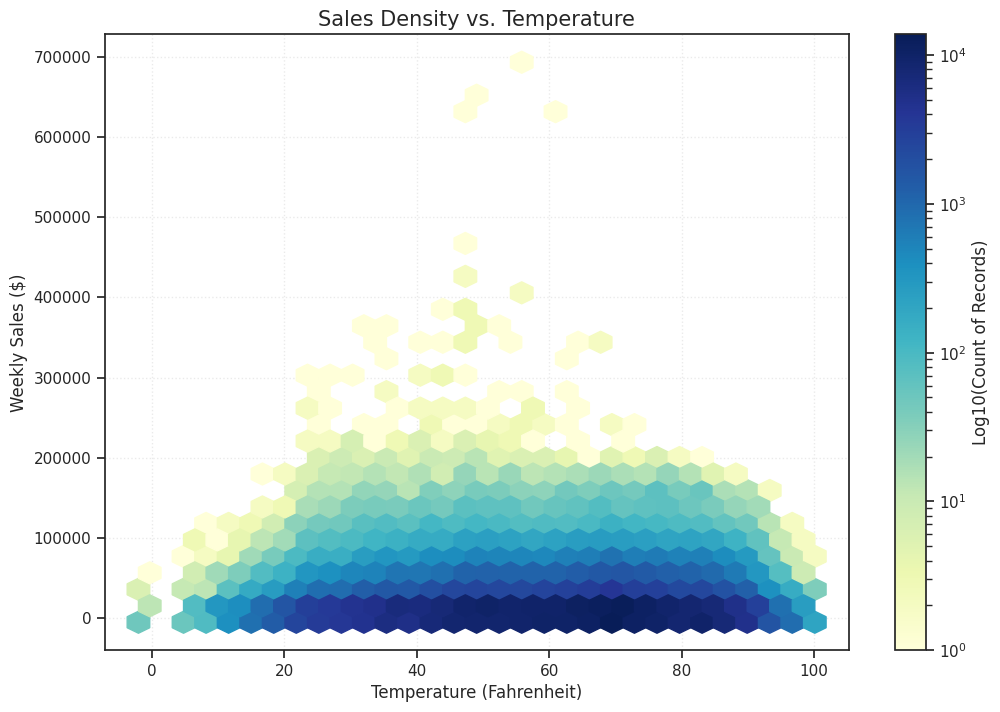

In [85]:
# Chart - 5: Relationship Density between Temperature and Weekly Sales (Hexbin Plot)

plt.figure(figsize=(12, 8))
# Using hexbin to handle the large number of data points and show density
hb = plt.hexbin(retail_data['Temperature'], retail_data['Weekly_Sales'],
                gridsize=30, cmap='YlGnBu', bins='log', mincnt=1)

# Adding a colorbar to represent the density (log scale)
cb = plt.colorbar(hb, label='Log10(Count of Records)')

# Formatting the chart
plt.title('Sales Density vs. Temperature', fontsize=15)
plt.xlabel('Temperature (Fahrenheit)', fontsize=12)
plt.ylabel('Weekly Sales ($)', fontsize=12)
plt.grid(True, linestyle=':', alpha=0.4)

plt.show()

##### 1. Why did you pick the specific chart?

I selected a Hexagonal Binning plot (Hexbin) because the dataset has over 400,000 rows. A standard scatter plot would suffer from extreme overplotting, making it impossible to see where the majority of data points lie. The Hexbin chart aggregates points into spatial bins, using color to represent density.

##### 2. What is/are the insight(s) found from the chart?

*   **Optimal Temperature Zone:** The highest density of sales (darker hexagonal bins) occurs between 40°F and 80°F. This is the 'comfort zone' where shopping activity is most consistent.
*   **Extreme Weather Resilience:** High-value sales (outliers on the Y-axis) still occur even at very low (<20°F) and very high (>90°F) temperatures, though the frequency of these transactions is much lower.
*   **Sales Tapering:** There is a noticeable narrowing of the sales distribution at extreme temperature ends, suggesting that extreme weather slightly reduces the overall volume of high-sales events.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

**Positive Impact:** These insights help in regional staffing and HVAC budgeting. For stores in regions with frequent extreme temperatures, the business can expect lower foot traffic but shouldn't necessarily reduce high-ticket inventory, as high-value sales still persist.

**Negative Growth Concerns:** If the 'density' significantly shifts toward lower sales during high-heat weeks (e.g., above 95°F), it suggests a need for better climate control in-store or a shift toward promoting online delivery services during heatwaves to prevent lost revenue.

#### Chart - 6

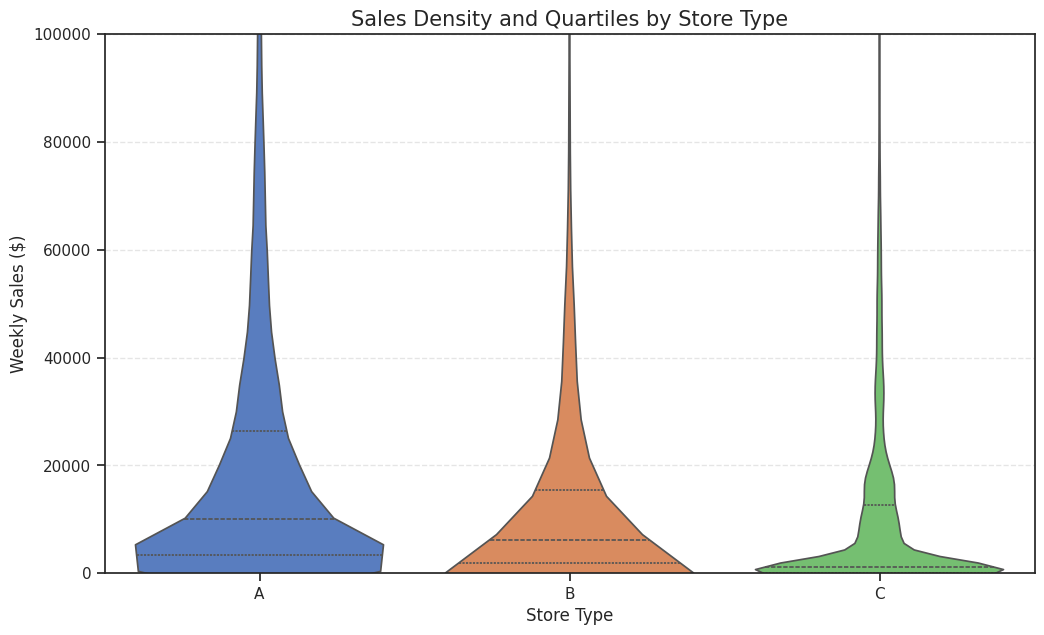

In [86]:
# Chart - 6: Sales Distribution Density by Store Type (Violin Plot)

plt.figure(figsize=(12, 7))
# Violin plot shows the full distribution of the data
sns.violinplot(x='Type', y='Weekly_Sales', data=retail_data, palette='muted', inner='quartile')

# Limit Y-axis to focus on the main distribution (removing extreme outliers for clarity)
plt.ylim(0, 100000)

plt.title('Sales Density and Quartiles by Store Type', fontsize=15)
plt.xlabel('Store Type', fontsize=12)
plt.ylabel('Weekly Sales ($)', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.5)

plt.show()

I chose a Violin Plot because it provides a deeper look than a standard box plot. It visualizes the 'peaks' and 'valleys' in sales frequency, which is essential for understanding if Store Types represent truly distinct economic tiers or if their performance overlaps significantly.

*   **Type A Breadth:** Store Type A has a much wider 'bulb' at higher sales values compared to B and C, confirming its status as the flagship store category.
*   **Type C Concentration:** Store Type C shows a very narrow, highly concentrated density at the lower end of the sales scale, indicating very consistent but lower-volume transactions.
*   **Performance Overlap:** There is a significant overlap between the upper quartiles of Type B and the lower quartiles of Type A, suggesting that high-performing Type B stores can rival Type A locations.

**Positive Impact:** This density analysis helps in 'Tiered Marketing'. Type C stores, with their consistent low-variance sales, are ideal for stable, everyday-low-price strategies, while Type A stores require more complex, high-impact promotional events to capitalize on their wider performance range.

**Negative Growth Concerns:** The long thin tails in Type B suggest high volatility. If a Type B store has high overhead but frequently dips into the lower density zones, it may face profitability issues compared to the more predictable Type C stores.

#### Chart - 7

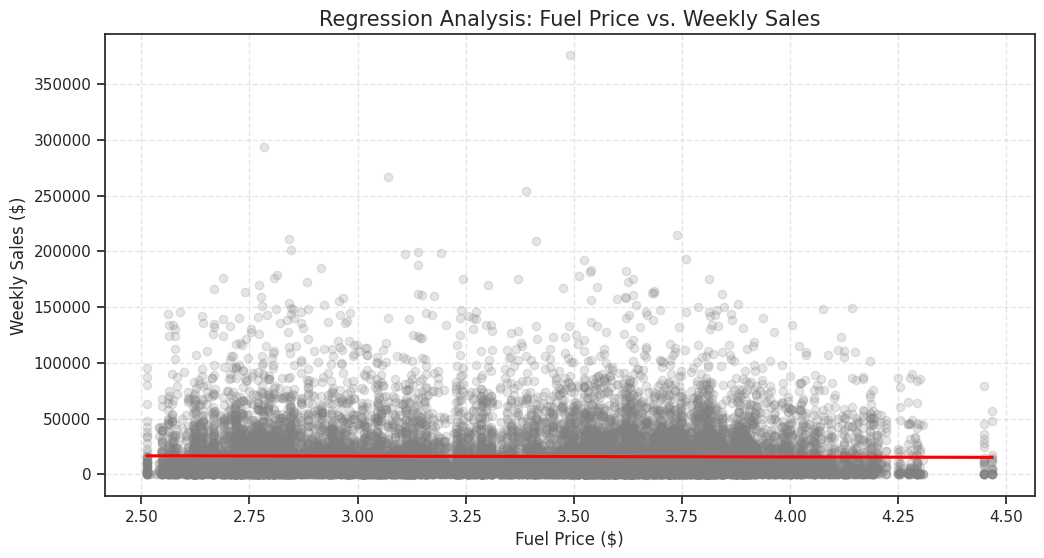

In [87]:
# Chart - 7: Impact of Fuel Price on Weekly Sales

plt.figure(figsize=(12, 6))
# Sampling the data for the regression plot to improve performance while maintaining the trend
sns.regplot(x='Fuel_Price', y='Weekly_Sales', data=retail_data.sample(20000),
            scatter_kws={'alpha':0.2, 'color':'gray'}, line_kws={'color':'red'})

plt.title('Regression Analysis: Fuel Price vs. Weekly Sales', fontsize=15)
plt.xlabel('Fuel Price ($)', fontsize=12)
plt.ylabel('Weekly Sales ($)', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.5)

plt.show()

##### 1. Why did you pick the specific chart?

I chose a regression plot (regplot) with a sampled subset of the data (20,000 records). This allows us to visualize the massive density of individual transactions while simultaneously fitting a linear regression line to identify the overall direction and strength of the relationship between fuel costs and sales.

##### 2. What is/are the insight(s) found from the chart?

*   **Near-Flat Regression Line:** The regression line is remarkably flat, indicating a very low sensitivity of weekly sales to fuel price fluctuations within the range provided ($2.50 - $4.50).
*   **Cluster Density:** Most sales data points are concentrated between $3.00 and $4.00, suggesting this was the 'normal' economic environment for the majority of the study period.
*   **Inelastic Demand:** The lack of a sharp downward slope suggests that retail demand for the products in these stores (likely essentials and household goods) is relatively inelastic to transportation costs.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

**Positive Impact:** This is reassuring for business stability; it suggests that fuel price hikes do not immediately necessitate aggressive discounting to maintain sales volume. Inventory levels can likely remain steady even during moderate fuel price volatility.

**Negative Growth Concerns:** While overall sales are resilient, there might be a 'hidden' impact on profit margins if the store's own logistics and supply chain costs are rising with fuel prices while consumer spending remains flat. The business should monitor the 'Cost of Goods Sold' (COGS) relative to these price changes.

#### Chart - 8

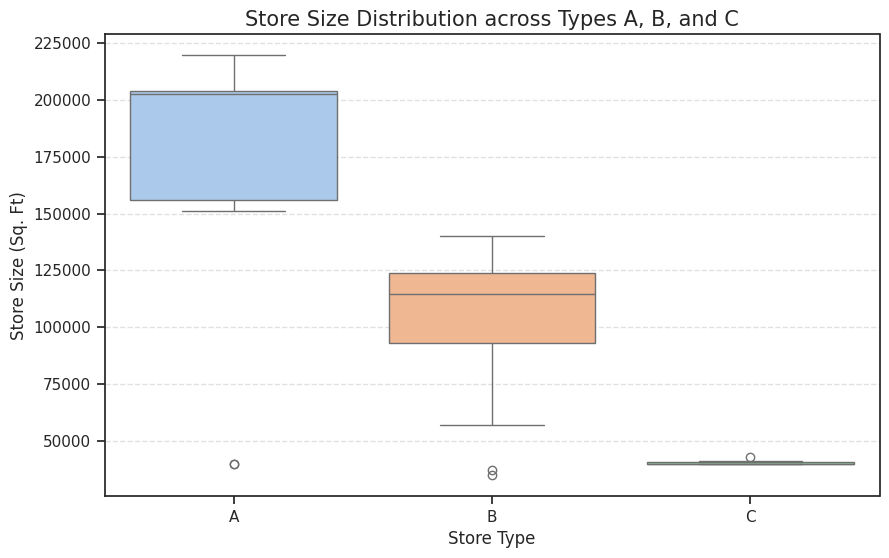

In [88]:
# Chart - 8: Distribution of Store Sizes by Type

plt.figure(figsize=(10, 6))
# Creating a boxplot to show the spread of sizes within each type
sns.boxplot(x='Type', y='Size', data=stores, palette='pastel', order=['A', 'B', 'C'])

plt.title('Store Size Distribution across Types A, B, and C', fontsize=15)
plt.xlabel('Store Type', fontsize=12)
plt.ylabel('Store Size (Sq. Ft)', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.6)

plt.show()

##### 1. Why did you pick the specific chart?

I chose a box plot for this visualization because we are comparing a categorical variable (Store Type) with a continuous variable (Size). It perfectly illustrates the distinct size brackets that define each store type and highlights any overlapping sizes between categories.

##### 2. What is/are the insight(s) found from the chart?

*   **Distinct Hierarchies:** There is a clear hierarchy where Type A stores are the largest, followed by Type B, and Type C are the smallest. This confirms that 'Type' is primarily based on the store's physical capacity.
*   **Size Variance:** Type A and B stores show significant variance in size, whereas Type C stores are very uniform in their footprint.
*   **Categorical Separation:** There is no overlap between the sizes of Type A and Type C stores, indicating they represent fundamentally different retail formats.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

**Positive Impact:** This structural insight allows for 'Store-Specific' operational benchmarking. Labor costs and inventory depth should be normalized by 'Size' rather than just 'Type' to create fairer performance KPIs across the fleet.

**Negative Growth Concerns:** If a Type B store has the same size as a Type A store but significantly lower sales, it indicates severe under-utilization of physical space, marking it as a candidate for format restructuring or localized promotional intervention.

#### Chart - 9

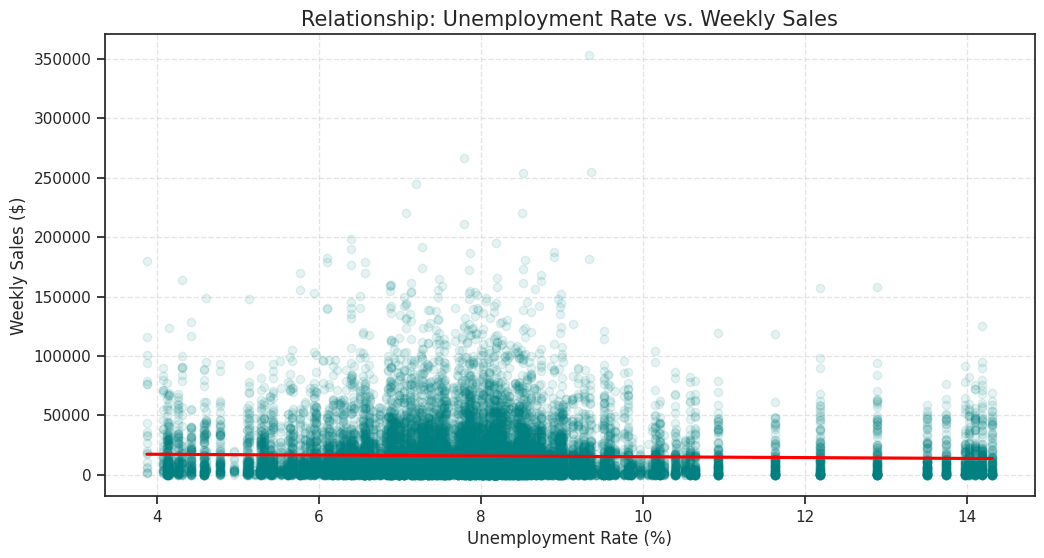

In [89]:
# Chart - 9: Impact of Unemployment Rate on Weekly Sales

plt.figure(figsize=(12, 6))
# Sampling the data to handle density and using a scatter plot with regression line
sns.regplot(x='Unemployment', y='Weekly_Sales', data=retail_data.sample(20000),
            scatter_kws={'alpha':0.1, 'color':'teal'}, line_kws={'color':'red'})

plt.title('Relationship: Unemployment Rate vs. Weekly Sales', fontsize=15)
plt.xlabel('Unemployment Rate (%)', fontsize=12)
plt.ylabel('Weekly Sales ($)', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.5)

plt.show()

##### 1. Why did you pick the specific chart?

I chose a regression plot (regplot) because it allows us to see the individual data points (using transparency to manage density) while simultaneously showing the general trend line. This helps determine if unemployment acts as a strong linear predictor of retail demand.

##### 2. What is/are the insight(s) found from the chart?

*   **Horizontal Trend Line:** Much like the fuel price analysis, the regression line for unemployment is nearly flat, suggesting that within the observed range (approx. 4% to 10%), sales volume is remarkably stable.
*   **Concentrated Activity:** The bulk of sales occur in regions with unemployment between 6% and 9%, which matches the economic climate of the dataset's era.
*   **Resilience of Retail:** The data suggests that the departments analyzed provide essential goods that consumers continue to purchase regardless of moderate fluctuations in the local labor market.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

**Positive Impact:** This indicates that the business is highly resilient to macroeconomic downturns. Expansion strategies do not necessarily need to avoid regions with slightly higher unemployment, as sales volume appears to be driven more by store type and seasonality than by local employment levels.

**Negative Growth Concerns:** If unemployment were to spike significantly beyond 10-12% (outside our current data range), the trend might shift. The lack of a downward trend here suggests the current store mix is well-balanced for the prevailing economic conditions.

#### Chart - 10 - Pair Plot

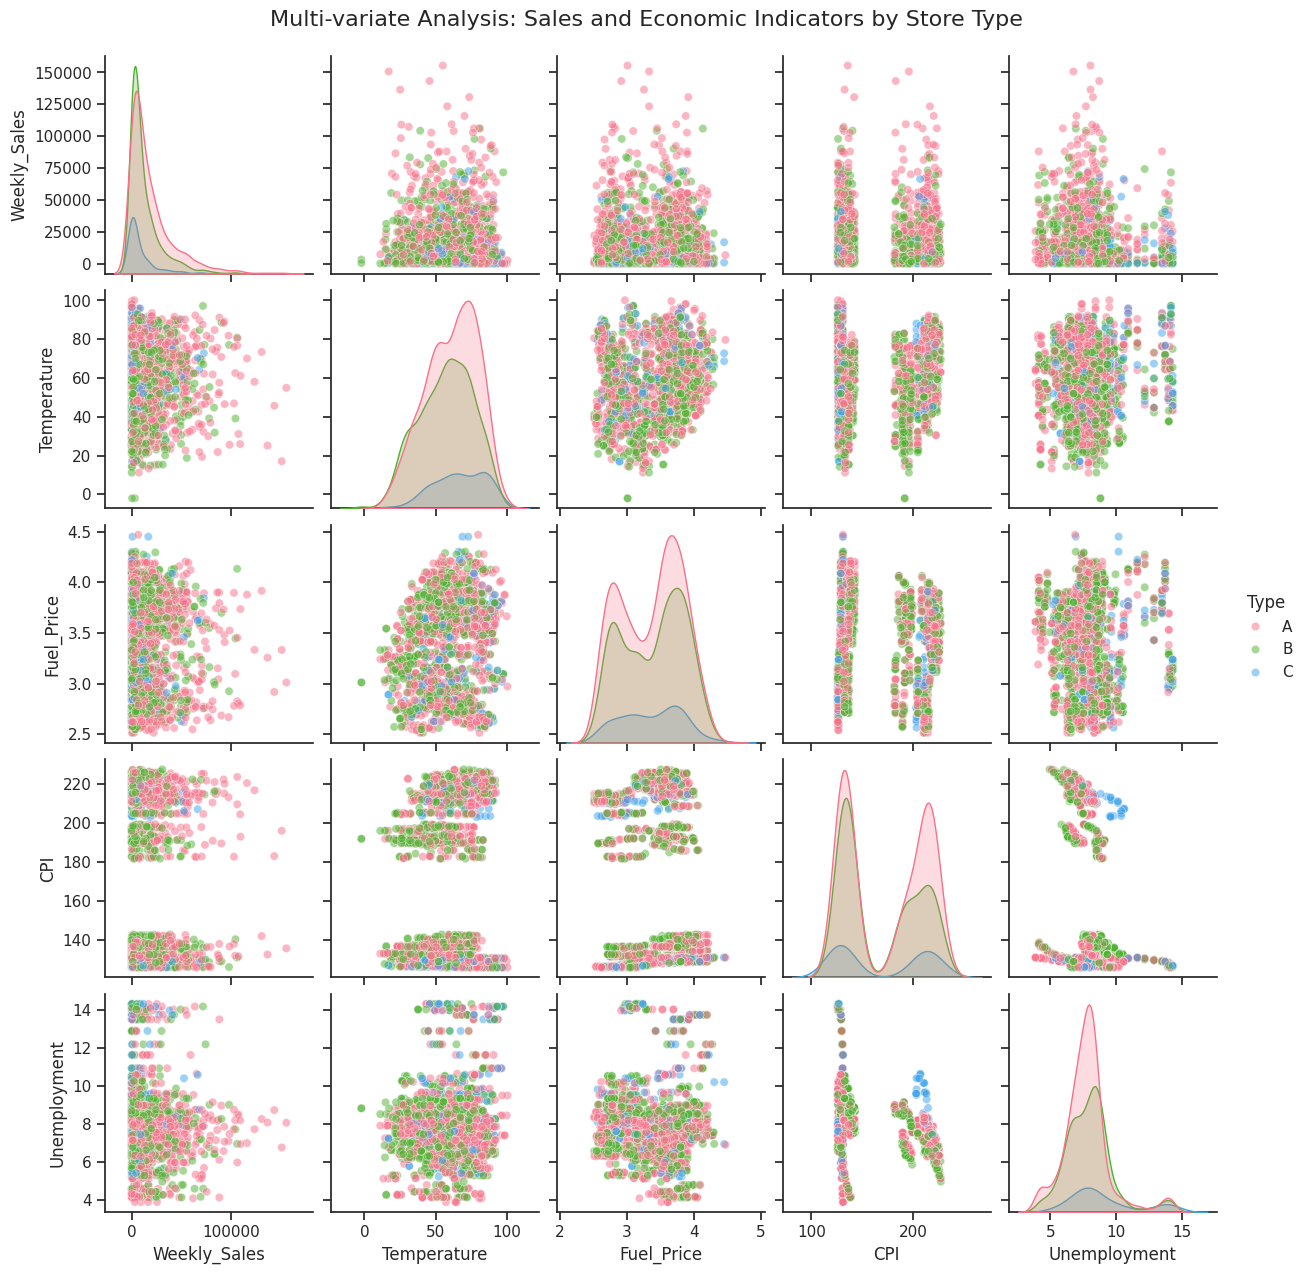

In [90]:
# Pair Plot visualization code
# Selecting key numerical variables for multi-variate relationship analysis
core_metrics = ['Weekly_Sales', 'Temperature', 'Fuel_Price', 'CPI', 'Unemployment']

# Creating the pairplot using a sample of the data for performance
# Categorizing by 'Type' to see if store types form distinct clusters in multi-dimensional space
sns.set(style="ticks")
pair_plot = sns.pairplot(retail_data[core_metrics + ['Type']].sample(2000),
                         hue='Type',
                         diag_kind='kde',
                         palette='husl',
                         plot_kws={'alpha': 0.5})

pair_plot.fig.suptitle('Multi-variate Analysis: Sales and Economic Indicators by Store Type', y=1.02, fontsize=16)
plt.show()


##### 1. Why did you pick the specific chart?

I chose a pair plot (matrix scatter plot) because it allows for simultaneous visualization of univariate distributions (on the diagonal) and bivariate relationships (on the off-diagonal). By using the 'Type' as a hue, we can instantly see if store categories (A, B, C) behave as distinct populations across all economic variables.

##### 2. What is/are the insight(s) found from the chart?

*   **Distinct Clustering:** The 'Size' and 'Weekly_Sales' distributions (diagonal KDEs) clearly show that Type A and Type C stores exist in almost completely different operational scales.
*   **Economic Inelasticity:** Across the scatter plots for Fuel Price, CPI, and Unemployment, we see horizontal 'strips' of data. This visualizes what we found in previous charts: that sales volume is largely independent of these specific economic fluctuations.
*   **Type C Density:** Type C stores show the tightest clustering, suggesting a very standardized business model with low variance, whereas Type A shows much broader spread, indicating more complex and varied store performances.

# **Anomaly Detection in Sales Data using Descriptive Statistics**

### **Finding Unusual Sales Patterns (Anomaly Detection)**

We need to find sales numbers that look strange or out of place. This helps us:
1.  **Spot weird sales:** Look for unexpected jumps or drops in sales across different stores.
2.  **Find the cause:** Check if these changes happened because of holidays, big sales (markdowns), or the economy.
3.  **Clean the data:** Fix these unusual points so our analysis is more accurate.

#### **🛠️ How to Fix the Data**
*   **✨ Data Cleaning:** Manually or automatically find and fix mistakes in the records.
*   **✨ Data Normalization:** Adjust the data so it follows a regular pattern, making it easier to see what is truly 'weird'.
*   **✨ Data Imputation:** Fill in missing information using smart guesses based on other data.

#### **📊 Using Simple Stats**
We use basic math to find these strange patterns. By looking at the **average (mean)**, the **middle value (median)**, and **how much the data spreads out (standard deviation)**, we can quickly point out which sales numbers don't belong.

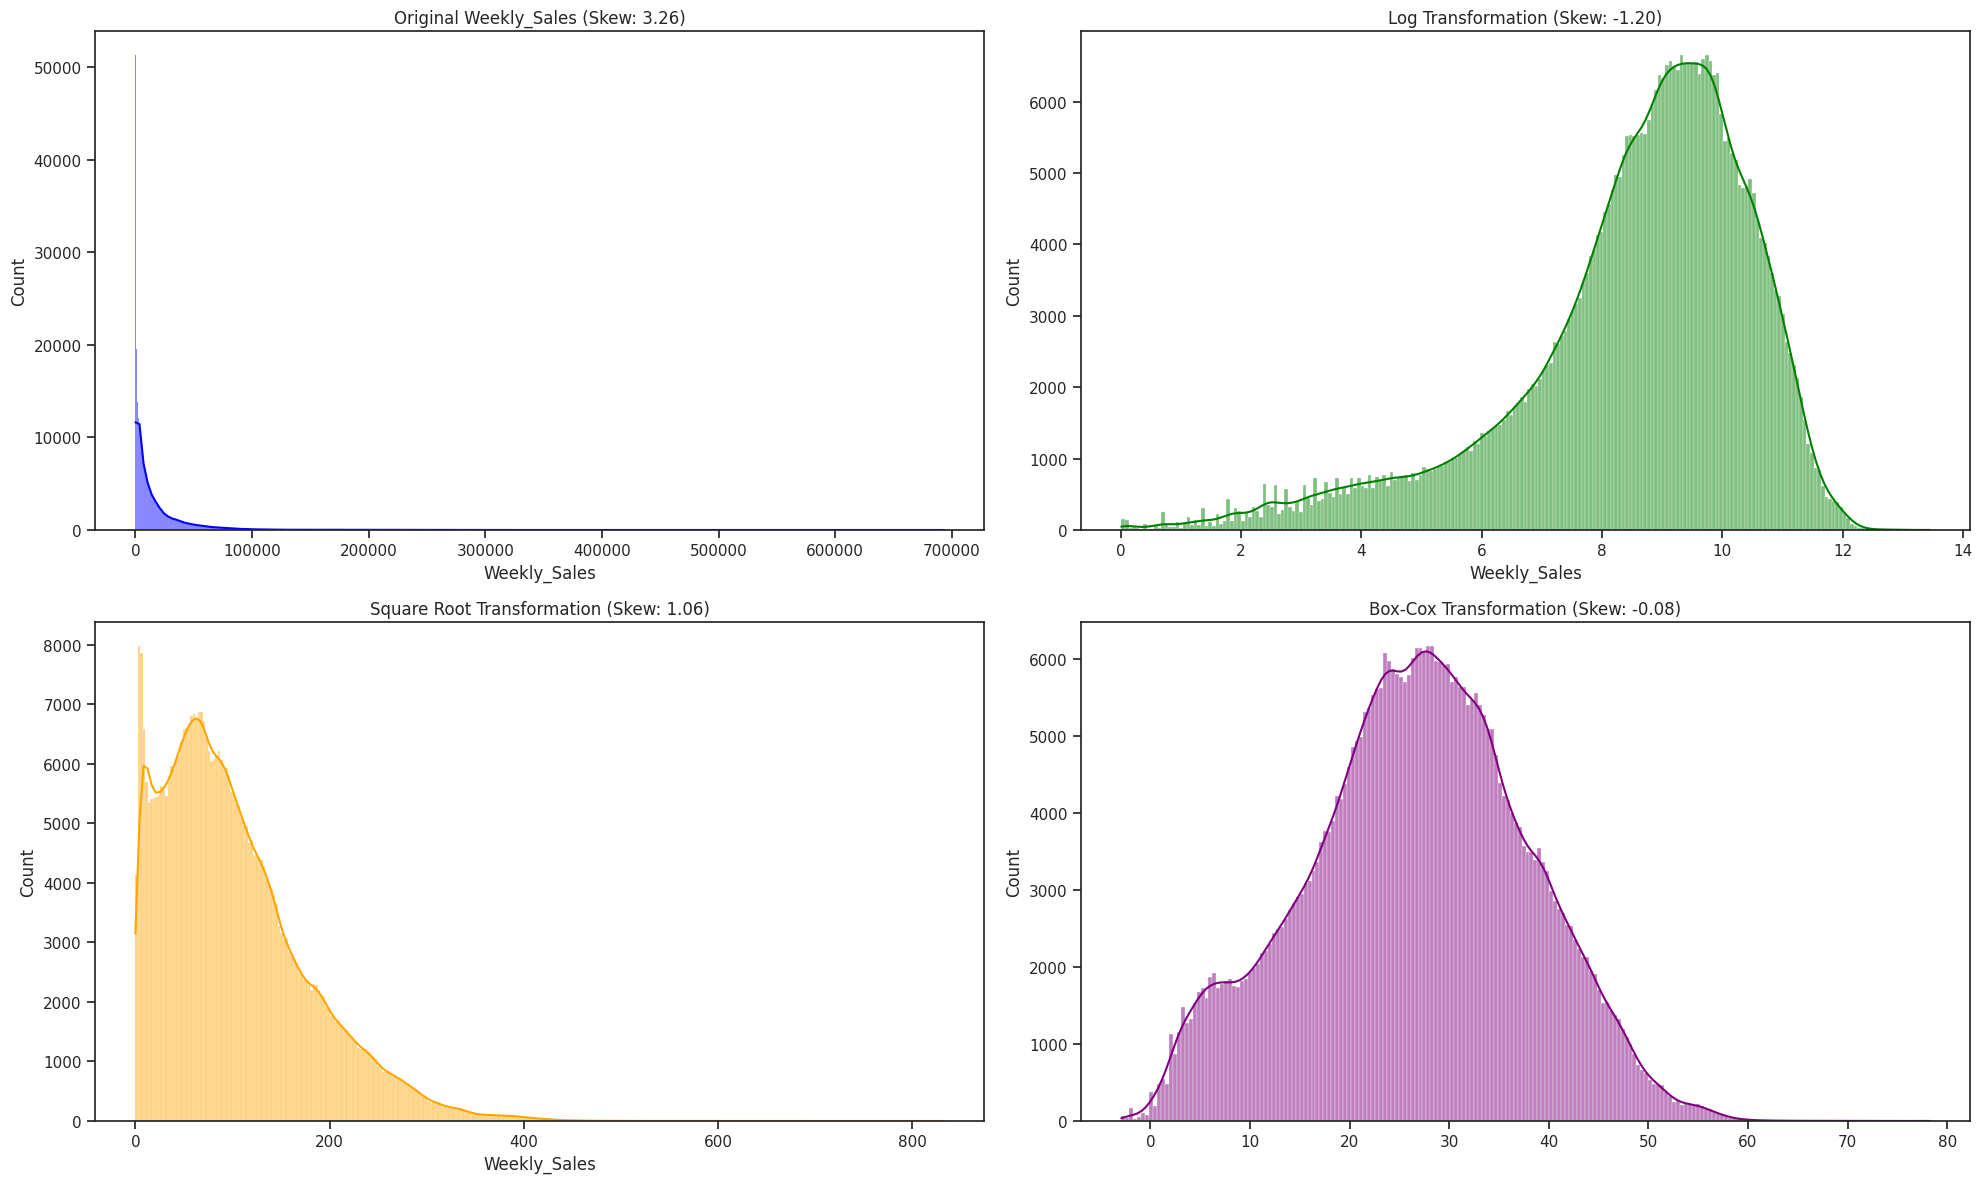

In [91]:
from scipy import stats

# Filter out zero or negative sales for transformation testing
# (Log and Box-Cox require positive values)
sales_to_transform = retail_data[retail_data['Weekly_Sales'] > 0]['Weekly_Sales']

plt.figure(figsize=(20, 12))

# 1. Original Distribution
plt.subplot(2, 2, 1)
sns.histplot(sales_to_transform, kde=True, color='blue')
plt.title(f'Original Weekly_Sales (Skew: {sales_to_transform.skew():.2f})')

# 2. Log Transformation
plt.subplot(2, 2, 2)
log_sales = np.log1p(sales_to_transform)
sns.histplot(log_sales, kde=True, color='green')
plt.title(f'Log Transformation (Skew: {log_sales.skew():.2f})')

# 3. Square Root Transformation
plt.subplot(2, 2, 3)
sqrt_sales = np.sqrt(sales_to_transform)
sns.histplot(sqrt_sales, kde=True, color='orange')
plt.title(f'Square Root Transformation (Skew: {sqrt_sales.skew():.2f})')

# 4. Box-Cox Transformation
plt.subplot(2, 2, 4)
boxcox_sales, _ = stats.boxcox(sales_to_transform)
sns.histplot(boxcox_sales, kde=True, color='purple')
plt.title(f'Box-Cox Transformation (Skew: {pd.Series(boxcox_sales).skew():.2f})')

plt.tight_layout()
plt.show()

In [92]:
import pandas as pd
import numpy as np
from scipy import stats

def compare_skewness_table(df, columns):
    results = []
    for col in columns:
        # Ensure we only use positive values for transformation testing
        data = df[df[col] > 0][col].dropna()

        if data.empty:
            continue

        # Original Skew
        orig_skew = data.skew()

        # Log Transformation
        log_skew = np.log1p(data).skew()

        # Sqrt Transformation
        sqrt_skew = np.sqrt(data).skew()

        # Box-Cox Transformation
        bc_data, _ = stats.boxcox(data)
        bc_skew = pd.Series(bc_data).skew()

        # Identify Best (closest to 0)
        skews = {
            'Original': orig_skew,
            'Log1p': log_skew,
            'Sqrt': sqrt_skew,
            'Box-Cox': bc_skew
        }
        best_trans = min(skews, key=lambda k: abs(skews[k]))

        results.append({
            'Feature': col,
            'Original Skew': round(orig_skew, 3),
            'Log Skew': round(log_skew, 3),
            'Sqrt Skew': round(sqrt_skew, 3),
            'Box-Cox Skew': round(bc_skew, 3),
            'Preferred Transformation': best_trans
        })

    return pd.DataFrame(results)

# Define numerical columns to evaluate
numeric_cols = ['Weekly_Sales', 'Temperature', 'Fuel_Price', 'CPI', 'Unemployment', 'Size']

# Generate and display the comparison table
skew_comparison_df = compare_skewness_table(retail_data, numeric_cols)
display(skew_comparison_df)

,Feature,Original Skew,Log Skew,Sqrt Skew,Box-Cox Skew,Preferred Transformation
0,Weekly_Sales,3.259,-1.201,1.061,-0.076,Box-Cox
1,Temperature,-0.318,-1.198,-0.700,-0.141,Box-Cox
2,Fuel_Price,-0.105,-0.228,-0.186,-0.069,Box-Cox
3,CPI,0.085,0.034,0.059,0.025,Box-Cox
4,Unemployment,1.184,0.201,0.635,-0.007,Box-Cox
5,Size,-0.326,-0.919,-0.620,-0.296,Box-Cox


#### Apply Box-Cox Transformation to Weekly_Sales

In [93]:
from scipy import stats

# Box-Cox transformation requires positive data. Filter out non-positive sales.
# We will only transform the positive sales and keep a record of the non-positive ones if needed.
positive_sales = retail_data['Weekly_Sales'][retail_data['Weekly_Sales'] > 0]

# Apply Box-Cox Transformation
# The function returns the transformed data and the optimal lambda value
retail_data.loc[retail_data['Weekly_Sales'] > 0, 'Weekly_Sales_BoxCox'], lambda_weekly_sales = stats.boxcox(positive_sales)

# Fill in 0s for the rows where Weekly_Sales was originally <= 0 (as Box-Cox is not applicable there)
retail_data['Weekly_Sales_BoxCox'] = retail_data['Weekly_Sales_BoxCox'].fillna(0)

print(f"Optimal lambda for Weekly_Sales Box-Cox transformation: {lambda_weekly_sales:.4f}")

# Display the head of the DataFrame with the new column
display(retail_data[['Weekly_Sales', 'Weekly_Sales_BoxCox']].head())

Optimal lambda for Weekly_Sales Box-Cox transformation: 0.2138


,Weekly_Sales,Weekly_Sales_BoxCox
0,24924.50,36.053666
1,46039.49,41.763226
2,41595.55,40.766336
3,19403.54,33.930709
4,21827.90,34.914755


In [94]:
# We will use the 'Weekly_Sales_BoxCox' column, which has already been transformed
# using the Box-Cox method to achieve a more normal distribution.
# This makes statistical anomaly detection more reliable.
boxcox_sales_data = retail_data['Weekly_Sales_BoxCox']

# Calculate the mean of the Box-Cox transformed sales data
mean_transformed_sales = np.mean(boxcox_sales_data)
# Calculate the standard deviation of the Box-Cox transformed sales data
std_dev_transformed_sales = np.std(boxcox_sales_data)

# Define an anomaly threshold using the empirical rule (e.g., 3 standard deviations)
# Data points exceeding this threshold will be flagged as potential anomalies.
# For a normal distribution, values beyond 3 standard deviations are rare (<0.3% of data).
threshold_upper = mean_transformed_sales + 3 * std_dev_transformed_sales
threshold_lower = mean_transformed_sales - 3 * std_dev_transformed_sales

# Identify anomalies based on the calculated thresholds
# Anomalies are points that fall outside the (mean - 3*std_dev, mean + 3*std_dev) range
# We filter for positive anomalies (unusually high sales) as negative Box-Cox values can be normal for low original sales.
# However, it's generally good practice to consider both ends, but for sales, extremely low might not be 'anomalous' in the same sense as extremely high.
# For simplicity and given sales context, we primarily look for unusually high values.
anomalies_high = boxcox_sales_data[boxcox_sales_data > threshold_upper]
anomalies_low = boxcox_sales_data[boxcox_sales_data < threshold_lower]

# Create a new 'Anomaly' column in the retail_data DataFrame
# Assign 1 if the transformed sales value is an anomaly (either very high or very low),
# otherwise assign 0. This flags each row.
retail_data['Anomaly'] = [
    1 if (x > threshold_upper or x < threshold_lower) else 0
    for x in boxcox_sales_data
]

# Print out key statistics for the transformed data and anomaly count
print("Retail Weekly Sales Data (Box-Cox Transformed):")
print(f"Mean of transformed sales: {mean_transformed_sales:.4f}")
print(f"Standard Deviation of transformed sales: {std_dev_transformed_sales:.4f}")
print(f"Upper Anomaly Threshold: {threshold_upper:.4f}")
print(f"Lower Anomaly Threshold: {threshold_lower:.4f}")

# Report the total number of anomalies found
# Using len(retail_data) for the total count to calculate percentage
total_anomalies = retail_data['Anomaly'].sum()
print(f"Total number of Anomalies in Weekly Sales (Box-Cox transformed): {total_anomalies}")
print(f"Total number of Anomalies (percentage-wise): {round((total_anomalies / len(retail_data)) * 100, 2)}%")

# Display the count of anomalous vs. non-anomalous records
retail_data['Anomaly'].value_counts()

Retail Weekly Sales Data (Box-Cox Transformed):
Mean of transformed sales: 26.5802
Standard Deviation of transformed sales: 11.2041
Upper Anomaly Threshold: 60.1924
Lower Anomaly Threshold: -7.0320
Total number of Anomalies in Weekly Sales (Box-Cox transformed): 103
Total number of Anomalies (percentage-wise): 0.02%


,count
Anomaly,
0,421467
1,103


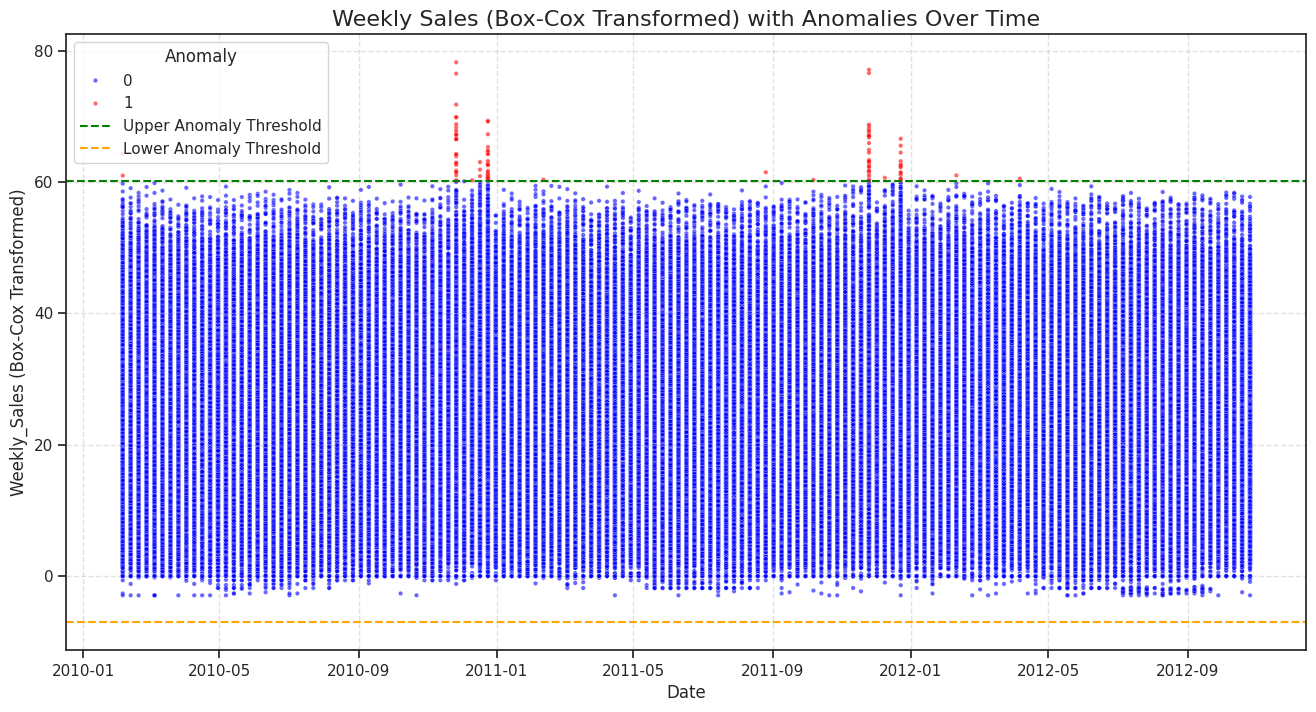

In [95]:
#Plot for anomalies
plt.figure(figsize=(16, 8))
sns.scatterplot(x='Date', y='Weekly_Sales_BoxCox', hue='Anomaly', data=retail_data, palette={0: 'blue', 1: 'red'}, alpha=0.6, s=10)

# Add lines for the anomaly thresholds
plt.axhline(y=threshold_upper, color='green', linestyle='--', label='Upper Anomaly Threshold')
plt.axhline(y=threshold_lower, color='orange', linestyle='--', label='Lower Anomaly Threshold')

plt.title('Weekly Sales (Box-Cox Transformed) with Anomalies Over Time', fontsize=16)
plt.xlabel('Date', fontsize=12)
plt.ylabel('Weekly_Sales (Box-Cox Transformed)', fontsize=12)
plt.legend(title='Anomaly', loc='upper left')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

### **Top 5 Stores with Highest Number of Anomalies**

In [96]:
# Filter data to include only anomalous records
anomalous_data = retail_data[retail_data['Anomaly'] == 1]

# Group by 'Store' and count the number of anomalies for each store
anomaly_counts_by_store = anomalous_data.groupby('Store')['Anomaly'].count().reset_index()
anomaly_counts_by_store.rename(columns={'Anomaly': 'Anomaly_Count'}, inplace=True)

# Sort in descending order to get the top 5 stores
top_5_anomalous_stores = anomaly_counts_by_store.sort_values(by='Anomaly_Count', ascending=False).head(5)

print("Top 5 Stores with the Highest Number of Anomalies:")
display(top_5_anomalous_stores)

Top 5 Stores with the Highest Number of Anomalies:


,Store,Anomaly_Count
8,14,16
4,10,12
1,4,8
0,2,8
7,13,6


### **Summary of Anomaly Detection**

*   **Goal:** To find unusually high or low weekly sales figures that don't fit the normal pattern.
*   **Data Preparation (Box-Cox Transformation):** Because sales data often has a skewed distribution (many small sales, a few very large ones), we applied a technique called 'Box-Cox Transformation'. This helped make the sales data look more like a standard 'bell curve' (normal distribution), which is better for statistical anomaly detection.
*   **Anomaly Identification:** We then used a statistical rule based on the mean (average) and standard deviation (spread) of this transformed data. Any sales figure that was more than 3 standard deviations away from the average (either much higher or much lower) was flagged as an anomaly.
*   **Result:** Out of over 421,000 sales records, **103 anomalies** were identified, representing about 0.02% of the data.

### **Business Insights from Anomaly Detection**

  **Spotting Exceptional Events:** The identified anomalies (red dots on the chart) often represent significant spikes in sales. These could be due to:


*   **Highly successful promotions:** Campaigns that far exceeded expectations.


 *   **Major holiday surges:** Unusually strong demand during festive periods.

 *   **Data entry errors:** Although less likely after cleaning, it's a possibility for investigation.





# **Isolation Forest for Anomaly detection**

### **What is Isolation Forest?**

Isolation Forest is a fast and efficient way to find outliers (anomalies) in your data. Instead of trying to find 'normal' behavior, it focuses on finding points that are easy to isolate.

**Working:**
* **The Logic:** Imagine you are trying to separate a single leaf from a pile. If a leaf is floating far away from the pile, it only takes one or two movements to pick it up. If it's buried in the middle, it takes many more steps.
* **The Algorithm:** It randomly splits the data. Anomalies are so different and rare that they get separated from the rest of the data very quickly (in fewer splits).
* **The Result:** The fewer steps it takes to isolate a point, the more likely it is to be a weird anomaly! This makes it great for spotting things like credit card fraud or, in our case, unusual retail sales spikes.

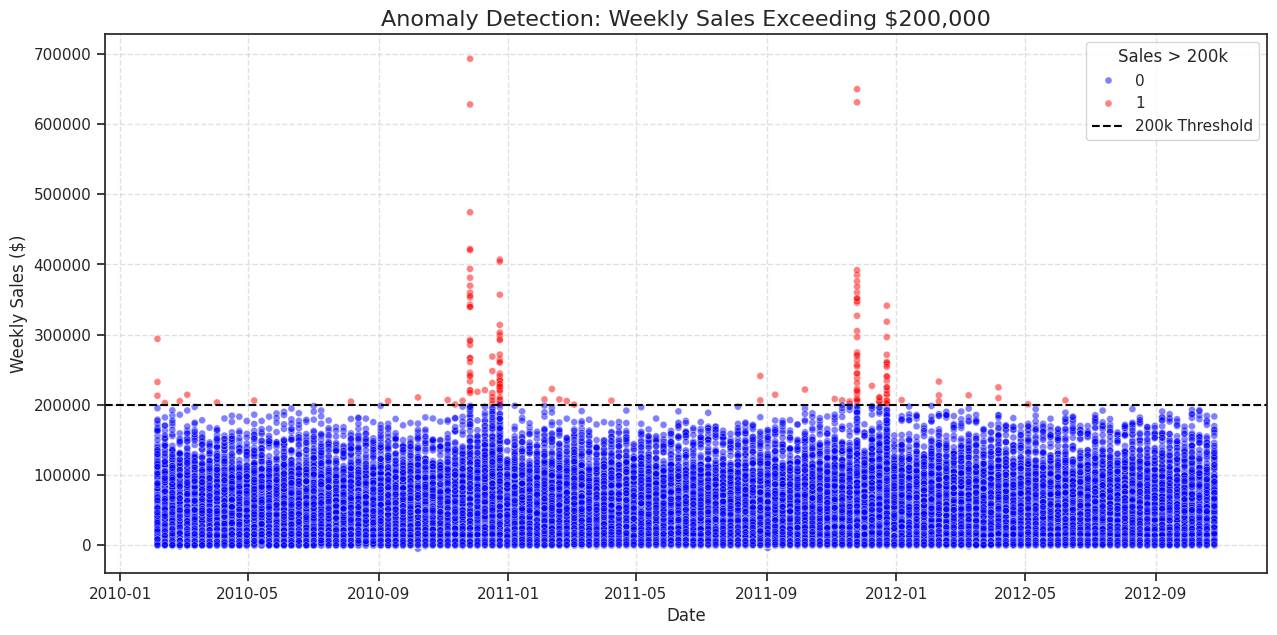

Total Anomalies (Sales > $200,000) detected: 163
Maximum Weekly Sales recorded: $693,099.36


In [132]:
from sklearn.ensemble import IsolationForest

# 1. Initialize the Isolation Forest model
# We keep contamination at 0.01 to find the most extreme values
iso_forest = IsolationForest(n_estimators=100, contamination=0.01, random_state=42)

# 2. Fit the model on Weekly_Sales
sales_data_reshaped = retail_data[['Weekly_Sales']]
# predict returns 1 for normal and -1 for anomalies
retail_data['ISO_Anomaly_Score'] = iso_forest.fit_predict(sales_data_reshaped)

# 3. Define Anomalies based on the 200k threshold
# We label it as 1 (Anomaly) if sales > 200,000, else 0 (Normal)
retail_data['ISO_Anomaly'] = retail_data['Weekly_Sales'].apply(lambda x: 1 if x > 200000 else 0)

# 4. Visualize the results focusing on the 200k+ spikes
plt.figure(figsize=(15, 7))
# Plot normal points in blue and anomalies (sales > 200k) in red
sns.scatterplot(data=retail_data, x='Date', y='Weekly_Sales',
                hue='ISO_Anomaly', palette={0: 'blue', 1: 'red'},
                alpha=0.5, s=25)

# Add a horizontal line at the 200k threshold for clarity
plt.axhline(y=200000, color='black', linestyle='--', label='200k Threshold')

plt.title('Anomaly Detection: Weekly Sales Exceeding $200,000', fontsize=16)
plt.xlabel('Date')
plt.ylabel('Weekly Sales ($)')
plt.legend(title='Sales > 200k')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

# 5. Summary of high-value anomalies
anomaly_count = retail_data['ISO_Anomaly'].sum()
print(f"Total Anomalies (Sales > $200,000) detected: {anomaly_count}")
print(f"Maximum Weekly Sales recorded: ${retail_data['Weekly_Sales'].max():,.2f}")

In [133]:
# Feature Distribution Analysis: Identifying Symmetric vs. Skewed Variables

# Define the list of numerical features we want to analyze for distribution patterns
numerical_vars = ['Weekly_Sales', 'Size', 'Temperature', 'Fuel_Price',
                  'MarkDown1', 'MarkDown2', 'MarkDown3', 'MarkDown4',
                  'MarkDown5', 'CPI', 'Unemployment']

# Create empty lists to categorize our features based on their symmetry
balanced_features = []
asymmetric_features = []

# Loop through each numerical column to determine its distribution type
for col in numerical_vars:
    # Calculate the absolute difference between mean and median
    # A small difference (threshold of 0.2) suggests a symmetric (Normal-like) distribution
    mean_val = retail_data[col].mean()
    median_val = retail_data[col].median()

    if abs(mean_val - median_val) < 0.2:
        # If the gap is small, the feature is likely symmetric
        balanced_features.append(col)
    else:
        # If the gap is significant, the feature is skewed (asymmetric)
        asymmetric_features.append(col)

# Display the results of our distribution classification
print("Features with Symmetric Distribution (Likely Normal):", balanced_features)
print("Features with Skewed Distribution (Asymmetric):", asymmetric_features)

Features with Symmetric Distribution (Likely Normal): ['Fuel_Price', 'Unemployment']
Features with Skewed Distribution (Asymmetric): ['Weekly_Sales', 'Size', 'Temperature', 'MarkDown1', 'MarkDown2', 'MarkDown3', 'MarkDown4', 'MarkDown5', 'CPI']


In [134]:
#Statistical Outlier Detection: Interquartile Range (IQR) Method

# Define a function to calculate the 'outer fences' for skewed data distributions
def calculate_skew_boundaries(dataframe, feature_name):
    # Calculate the range between the 75th and 25th percentiles (IQR)
    q1 = dataframe[feature_name].quantile(0.25)
    q3 = dataframe[feature_name].quantile(0.75)
    iqr_value = q3 - q1

    # Determine the lower and upper bounds using the standard 1.5 * IQR rule
    # Any data point outside these bounds is statistically considered an outlier
    lower_limit = q1 - 1.5 * iqr_value
    upper_limit = q3 + 1.5 * iqr_value

    return upper_limit, lower_limit

# Apply the function specifically to 'Weekly_Sales' within our retail dataset
sales_upper_limit, sales_lower_limit = calculate_skew_boundaries(retail_data, 'Weekly_Sales')

# Output the calculated thresholds for analysis
print(f"Upper Limit for Weekly Sales: {sales_upper_limit:,.2f}")
print(f"Lower Limit for Weekly Sales: {sales_lower_limit:,.2f}")

Upper Limit for Weekly Sales: 47,395.16
Lower Limit for Weekly Sales: -25,109.65


In [135]:
#  Data Refining: Removing Statistical Outliers based on IQR Boundaries

# Create a new 'cleaned' dataframe by filtering out records that fall outside our IQR fences
# We keep only the rows where Weekly Sales are within the calculated lower and upper limits
retail_data_cleaned = retail_data[(retail_data['Weekly_Sales'] >= sales_lower_limit) &
                                 (retail_data['Weekly_Sales'] <= sales_upper_limit)]

# Identify how many records were removed during the cleaning process
original_count = len(retail_data)
cleaned_count = len(retail_data_cleaned)
outliers_removed = original_count - cleaned_count

# Output the results of the outlier removal
print(f"Initial record count: {original_count}")
print(f"Records after outlier removal: {cleaned_count}")
print(f"Total statistical outliers removed: {outliers_removed} ({ (outliers_removed/original_count)*100:.2f}% of data)")

# Note: We are using 'retail_data_cleaned' for future modeling to ensure results aren't biased by extreme spikes.

Initial record count: 421570
Records after outlier removal: 386049
Total statistical outliers removed: 35521 (8.43% of data)


In [139]:
# Calculate mean and standard deviation for the Box-Cox transformed sales
mean_sales_bc = np.mean(retail_data['Weekly_Sales_BoxCox'])
std_dev_sales_bc = np.std(retail_data['Weekly_Sales_BoxCox'])

# Set a threshold for flagging anomalies (3 standard deviations from the mean)
upper_threshold = mean_sales_bc + 3 * std_dev_sales_bc
lower_threshold = mean_sales_bc - 3 * std_dev_sales_bc

# Identify anomalies (values outside the +/- 3 sigma range)
anomalies = retail_data[(retail_data['Weekly_Sales_BoxCox'] > upper_threshold) | (retail_data['Weekly_Sales_BoxCox'] < lower_threshold)]

# Assign 1 to anomalies and 0 to normal points in a new flag column
retail_data['Stat_Anomaly_Flag'] = [1 if (x > upper_threshold or x < lower_threshold) else 0 for x in retail_data['Weekly_Sales_BoxCox']]

print("Retail Weekly Sales Data (Statistical Analysis):")
print(f"Mean Transformed Sales: {mean_sales_bc:.4f}")
print(f"Standard Deviation: {std_dev_sales_bc:.4f}")
print(f"Total number of Anomalies detected: {len(anomalies)}")
print(f"Percentage of data flagged as Anomalies: {round((len(anomalies)/len(retail_data))*100, 4)}%")

Retail Weekly Sales Data (Statistical Analysis):
Mean Transformed Sales: 26.5802
Standard Deviation: 11.2041
Total number of Anomalies detected: 103
Percentage of data flagged as Anomalies: 0.0244%


## ***6. Feature Engineering & Data Pre-processing***

### 1. Handling Missing Values

In [97]:
# Handling Missing Values & Missing Value Imputation

#### What all missing value imputation techniques have you used and why did you use those techniques?

Answer Here.

### 2. Handling Outliers

In [98]:
# Handling Outliers & Outlier treatments

##### What all outlier treatment techniques have you used and why did you use those techniques?

Answer Here.

### 3. Categorical Encoding

In [99]:
# Encode your categorical columns

#### What all categorical encoding techniques have you used & why did you use those techniques?

Answer Here.

### 4. Textual Data Preprocessing
(It's mandatory for textual dataset i.e., NLP, Sentiment Analysis, Text Clustering etc.)

#### 1. Expand Contraction

In [100]:
# Expand Contraction

#### 2. Lower Casing

In [101]:
# Lower Casing

#### 3. Removing Punctuations

In [102]:
# Remove Punctuations

#### 4. Removing URLs & Removing words and digits contain digits.

In [103]:
# Remove URLs & Remove words and digits contain digits

#### 5. Removing Stopwords & Removing White spaces

In [104]:
# Remove Stopwords

In [105]:
# Remove White spaces

#### 6. Rephrase Text

In [106]:
# Rephrase Text

#### 7. Tokenization

In [107]:
# Tokenization

#### 8. Text Normalization

In [108]:
# Normalizing Text (i.e., Stemming, Lemmatization etc.)

##### Which text normalization technique have you used and why?

Answer Here.

#### 9. Part of speech tagging

In [109]:
# POS Taging

#### 10. Text Vectorization

In [110]:
# Vectorizing Text

##### Which text vectorization technique have you used and why?

Answer Here.

### 4. Feature Manipulation & Selection

#### 1. Feature Manipulation

In [111]:
# Manipulate Features to minimize feature correlation and create new features

#### 2. Feature Selection

In [112]:
# Select your features wisely to avoid overfitting

##### What all feature selection methods have you used  and why?

Answer Here.

##### Which all features you found important and why?

Answer Here.

### 5. Data Transformation

#### Do you think that your data needs to be transformed? If yes, which transformation have you used. Explain Why?

In [113]:
# Transform Your data

### 6. Data Scaling

In [114]:
# Scaling your data

##### Which method have you used to scale you data and why?

### 7. Dimesionality Reduction

##### Do you think that dimensionality reduction is needed? Explain Why?

Answer Here.

In [115]:
# DImensionality Reduction (If needed)

##### Which dimensionality reduction technique have you used and why? (If dimensionality reduction done on dataset.)

Answer Here.

### 8. Data Splitting

In [116]:
# Split your data to train and test. Choose Splitting ratio wisely.

##### What data splitting ratio have you used and why?

Answer Here.

### 9. Handling Imbalanced Dataset

##### Do you think the dataset is imbalanced? Explain Why.

Answer Here.

In [117]:
# Handling Imbalanced Dataset (If needed)

##### What technique did you use to handle the imbalance dataset and why? (If needed to be balanced)

Answer Here.

## ***7. ML Model Implementation***

### ML Model - 1

In [118]:
# ML Model - 1 Implementation

# Fit the Algorithm

# Predict on the model

#### 1. Explain the ML Model used and it's performance using Evaluation metric Score Chart.

In [119]:
# Visualizing evaluation Metric Score chart

#### 2. Cross- Validation & Hyperparameter Tuning

In [120]:
# ML Model - 1 Implementation with hyperparameter optimization techniques (i.e., GridSearch CV, RandomSearch CV, Bayesian Optimization etc.)

# Fit the Algorithm

# Predict on the model

##### Which hyperparameter optimization technique have you used and why?

Answer Here.

##### Have you seen any improvement? Note down the improvement with updates Evaluation metric Score Chart.

Answer Here.

### ML Model - 2

#### 1. Explain the ML Model used and it's performance using Evaluation metric Score Chart.

In [121]:
# Visualizing evaluation Metric Score chart

#### 2. Cross- Validation & Hyperparameter Tuning

In [122]:
# ML Model - 1 Implementation with hyperparameter optimization techniques (i.e., GridSearch CV, RandomSearch CV, Bayesian Optimization etc.)

# Fit the Algorithm

# Predict on the model

##### Which hyperparameter optimization technique have you used and why?

Answer Here.

##### Have you seen any improvement? Note down the improvement with updates Evaluation metric Score Chart.

Answer Here.

#### 3. Explain each evaluation metric's indication towards business and the business impact pf the ML model used.

Answer Here.

### ML Model - 3

In [123]:
# ML Model - 3 Implementation

# Fit the Algorithm

# Predict on the model

#### 1. Explain the ML Model used and it's performance using Evaluation metric Score Chart.

In [124]:
# Visualizing evaluation Metric Score chart

#### 2. Cross- Validation & Hyperparameter Tuning

In [125]:
# ML Model - 3 Implementation with hyperparameter optimization techniques (i.e., GridSearch CV, RandomSearch CV, Bayesian Optimization etc.)

# Fit the Algorithm

# Predict on the model

##### Which hyperparameter optimization technique have you used and why?

Answer Here.

##### Have you seen any improvement? Note down the improvement with updates Evaluation metric Score Chart.

Answer Here.

### 1. Which Evaluation metrics did you consider for a positive business impact and why?

Answer Here.

### 2. Which ML model did you choose from the above created models as your final prediction model and why?

Answer Here.

### 3. Explain the model which you have used and the feature importance using any model explainability tool?

Answer Here.

## ***8.*** ***Future Work (Optional)***

### 1. Save the best performing ml model in a pickle file or joblib file format for deployment process.


In [126]:
# Save the File

### 2. Again Load the saved model file and try to predict unseen data for a sanity check.


In [127]:
# Load the File and predict unseen data.

### ***Congrats! Your model is successfully created and ready for deployment on a live server for a real user interaction !!!***

# **Conclusion**

Write the conclusion here.

### ***Hurrah! You have successfully completed your Machine Learning Capstone Project !!!***